# Requisitos

In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install librosa scikit-fuzzy pymoo scikit-learn numpy pandas matplotlib seaborn tqdm scipy statsmodels

Looking in indexes: https://download.pytorch.org/whl/cu118


# Imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# pymoo imports
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination

import random
import time
import gc
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memória disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Seed para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Usando dispositivo: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memória disponível: 4.29 GB


In [3]:
from PIL import Image
import os
from pathlib import Path

class GTZANSpectrogramDataset(Dataset):
    """Dataset GTZAN carregando espectrogramas PNG já gerados"""
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir: Caminho para a pasta com as classes (gêneros musicais)
                     Ex: C:/Users/caio.grasso/Desktop/Mestrado/data/gtzan/spectrograms
            transform: Transformações a aplicar nas imagens
        """
        self.root_dir = Path(root_dir)
        self.transform = transform
        
        # Coletar todos os arquivos de imagem e suas classes
        self.samples = []
        self.class_to_idx = {}
        
        # Listar todas as pastas (gêneros musicais)
        class_folders = sorted([d for d in self.root_dir.iterdir() if d.is_dir()])
        
        print(f"\n🎵 Carregando GTZAN de: {root_dir}")
        print(f"🔍 Gêneros musicais encontrados: {len(class_folders)}")
        
        for idx, class_folder in enumerate(class_folders):
            class_name = class_folder.name
            self.class_to_idx[class_name] = idx
            
            # Listar todos os arquivos PNG na pasta do gênero
            image_files = list(class_folder.glob("*.png"))
            
            for img_path in image_files:
                self.samples.append((str(img_path), idx))
        
        print(f"✓ Total de amostras: {len(self.samples)}")
        print(f"✓ Número de gêneros: {len(self.class_to_idx)}")
        print(f"✓ Gêneros: {list(self.class_to_idx.keys())}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Carregar imagem PNG
        image = Image.open(img_path).convert('RGB')
        
        # Aplicar transformações
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Configurar transformações para resize e normalização
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Redimensionar para 224x224
    transforms.ToTensor(),  # Converter para tensor [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalização ImageNet
                        std=[0.229, 0.224, 0.225])
])

# Caminho para os espectrogramas GTZAN
GTZAN_PATH = r"C:\Users\caio.grasso\Desktop\Mestrado\data\gtzan\images_original"

print("\n=== Carregando Dataset GTZAN ===")

# Carregar dataset completo
full_dataset = GTZANSpectrogramDataset(GTZAN_PATH, transform=transform)

# Obter informações do dataset
num_classes = len(full_dataset.class_to_idx)
num_samples = len(full_dataset)

print(f"\n📊 Informações do Dataset GTZAN:")
print(f"  - Total de amostras: {num_samples}")
print(f"  - Número de gêneros musicais: {num_classes}")
print(f"  - Tamanho das imagens: 224x224")
print(f"  - Gêneros: {', '.join(full_dataset.class_to_idx.keys())}")

# Split: 70% treino, 15% validação, 15% teste
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

# Usar random_split do PyTorch
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n📂 Divisão do Dataset:")
print(f"  ✓ Treino: {len(train_dataset)} amostras ({len(train_dataset)/num_samples*100:.1f}%)")
print(f"  ✓ Validação: {len(val_dataset)} amostras ({len(val_dataset)/num_samples*100:.1f}%)")
print(f"  ✓ Teste: {len(test_dataset)} amostras ({len(test_dataset)/num_samples*100:.1f}%)")
print(f"  ✓ Dataset GTZAN pronto para uso! 🎸🎹🎺")


=== Carregando Dataset GTZAN ===

🎵 Carregando GTZAN de: C:\Users\caio.grasso\Desktop\Mestrado\data\gtzan\images_original
🔍 Gêneros musicais encontrados: 10
✓ Total de amostras: 999
✓ Número de gêneros: 10
✓ Gêneros: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

📊 Informações do Dataset GTZAN:
  - Total de amostras: 999
  - Número de gêneros musicais: 10
  - Tamanho das imagens: 224x224
  - Gêneros: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock

📂 Divisão do Dataset:
  ✓ Treino: 699 amostras (70.0%)
  ✓ Validação: 149 amostras (14.9%)
  ✓ Teste: 151 amostras (15.1%)
  ✓ Dataset GTZAN pronto para uso! 🎸🎹🎺


In [4]:
class TransferLearningModel(nn.Module):
    """Modelo com backbone congelado - adaptável ao número de classes"""
    def __init__(self, model_idx, num_classes):
        super(TransferLearningModel, self).__init__()
        
        # Selecionar modelo base (AMPLIADO PARA 4 MODELOS)
        if model_idx == 0:
            # ResNet18 - Rápido e eficiente
            self.backbone = models.resnet18(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        elif model_idx == 1:
            # ResNet34 - Mais profundo que ResNet18
            self.backbone = models.resnet34(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        elif model_idx == 2:
            # MobileNetV2 - Leve e eficiente
            self.backbone = models.mobilenet_v2(pretrained=True)
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        else:  # model_idx == 3
            # EfficientNet-B0 - Estado da arte em eficiência
            self.backbone = models.efficientnet_b0(pretrained=True)
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        
        # Congelar backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Cabeça classificadora MELHORADA (mais capacidade)
        if num_classes <= 10:
            # GTZAN (10 classes) - arquitetura mais profunda
            self.classifier = nn.Sequential(
                nn.Linear(num_features, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )
        else:
            # Muitas classes - arquitetura ainda mais profunda
            self.classifier = nn.Sequential(
                nn.Linear(num_features, 1024),
                nn.BatchNorm1d(1024),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(1024, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )
        
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

print(f"✓ Modelos configurados: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0")
print(f"✓ Classificador para {num_classes} classes com BatchNorm")

✓ Modelos configurados: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0
✓ Classificador para 10 classes com BatchNorm


In [9]:
def create_fuzzy_system(metric_type):
    """
    Cria sistema fuzzy MAIS PERMISSIVO para agregação de métricas
    metric_type: 'eval', 'ood', ou 'performance'
    """
    
    if metric_type == 'eval':
        # Evaluation Metrics: Accuracy, Precision, F1-Score
        accuracy = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'accuracy')
        precision = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'precision')
        f1 = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'f1')
        
        # Membership functions MAIS PERMISSIVAS
        accuracy['low'] = fuzz.trimf(accuracy.universe, [0, 0, 0.5])
        accuracy['medium'] = fuzz.trimf(accuracy.universe, [0.3, 0.6, 0.8])
        accuracy['high'] = fuzz.trimf(accuracy.universe, [0.6, 1.0, 1.0])
        
        precision['low'] = fuzz.trimf(precision.universe, [0, 0, 0.5])
        precision['medium'] = fuzz.trimf(precision.universe, [0.3, 0.6, 0.8])
        precision['high'] = fuzz.trimf(precision.universe, [0.6, 1.0, 1.0])
        
        f1['low'] = fuzz.trimf(f1.universe, [0, 0, 0.5])
        f1['medium'] = fuzz.trimf(f1.universe, [0.3, 0.6, 0.8])
        f1['high'] = fuzz.trimf(f1.universe, [0.6, 1.0, 1.0])
        
        fitness = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'fitness')
        fitness['very_low'] = fuzz.trimf(fitness.universe, [0, 0, 0.25])
        fitness['low'] = fuzz.trimf(fitness.universe, [0.15, 0.35, 0.55])
        fitness['medium'] = fuzz.trimf(fitness.universe, [0.4, 0.6, 0.8])
        fitness['high'] = fuzz.trimf(fitness.universe, [0.65, 0.85, 1.0])
        fitness['very_high'] = fuzz.trimf(fitness.universe, [0.85, 1.0, 1.0])
        
        # Regras fuzzy MAIS GENEROSAS
        rules = [
            ctrl.Rule(accuracy['high'] & precision['high'] & f1['high'], fitness['very_high']),
            ctrl.Rule(accuracy['high'] & precision['high'], fitness['very_high']),
            ctrl.Rule(accuracy['high'] & f1['high'], fitness['high']),
            ctrl.Rule(accuracy['high'] | (precision['high'] & f1['high']), fitness['high']),
            ctrl.Rule(accuracy['medium'] & precision['medium'] & f1['medium'], fitness['medium']),
            ctrl.Rule(accuracy['medium'] & precision['medium'], fitness['medium']),
            ctrl.Rule(accuracy['medium'] | precision['medium'] | f1['medium'], fitness['low']),
            ctrl.Rule(accuracy['low'] & precision['low'] & f1['low'], fitness['very_low']),
        ]
        
    elif metric_type == 'ood':
        # OOD Metrics: AUROC, AUPR, FPR
        auroc = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'auroc')
        aupr = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'aupr')
        fpr = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'fpr')
        
        auroc['low'] = fuzz.trimf(auroc.universe, [0, 0, 0.6])
        auroc['medium'] = fuzz.trimf(auroc.universe, [0.5, 0.7, 0.85])
        auroc['high'] = fuzz.trimf(auroc.universe, [0.75, 1.0, 1.0])
        
        aupr['low'] = fuzz.trimf(aupr.universe, [0, 0, 0.4])
        aupr['medium'] = fuzz.trimf(aupr.universe, [0.3, 0.5, 0.7])
        aupr['high'] = fuzz.trimf(aupr.universe, [0.6, 1.0, 1.0])
        
        fpr['low'] = fuzz.trimf(fpr.universe, [0, 0, 0.3])  # low FPR é bom
        fpr['medium'] = fuzz.trimf(fpr.universe, [0.2, 0.5, 0.7])
        fpr['high'] = fuzz.trimf(fpr.universe, [0.6, 1.0, 1.0])
        
        fitness = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'fitness')
        fitness['very_low'] = fuzz.trimf(fitness.universe, [0, 0, 0.25])
        fitness['low'] = fuzz.trimf(fitness.universe, [0.15, 0.35, 0.55])
        fitness['medium'] = fuzz.trimf(fitness.universe, [0.4, 0.6, 0.8])
        fitness['high'] = fuzz.trimf(fitness.universe, [0.65, 0.85, 1.0])
        fitness['very_high'] = fuzz.trimf(fitness.universe, [0.85, 1.0, 1.0])
        
        rules = [
            ctrl.Rule(auroc['high'] & aupr['high'] & fpr['low'], fitness['very_high']),
            ctrl.Rule(auroc['high'] & aupr['high'], fitness['high']),
            ctrl.Rule(auroc['high'] & fpr['low'], fitness['high']),
            ctrl.Rule(auroc['medium'] & aupr['medium'], fitness['medium']),
            ctrl.Rule(auroc['medium'] | aupr['medium'], fitness['low']),
            ctrl.Rule(auroc['low'] | aupr['low'], fitness['very_low']),
        ]
        
    else:  # performance
        # Performance Metrics: Latency, Memory (já normalizados invertidos)
        latency = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'latency')
        memory = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'memory')
        
        latency['low'] = fuzz.trimf(latency.universe, [0, 0, 0.4])
        latency['medium'] = fuzz.trimf(latency.universe, [0.3, 0.6, 0.8])
        latency['high'] = fuzz.trimf(latency.universe, [0.7, 1.0, 1.0])
        
        memory['low'] = fuzz.trimf(memory.universe, [0, 0, 0.4])
        memory['medium'] = fuzz.trimf(memory.universe, [0.3, 0.6, 0.8])
        memory['high'] = fuzz.trimf(memory.universe, [0.7, 1.0, 1.0])
        
        fitness = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'fitness')
        fitness['very_low'] = fuzz.trimf(fitness.universe, [0, 0, 0.25])
        fitness['low'] = fuzz.trimf(fitness.universe, [0.15, 0.35, 0.55])
        fitness['medium'] = fuzz.trimf(fitness.universe, [0.4, 0.6, 0.8])
        fitness['high'] = fuzz.trimf(fitness.universe, [0.65, 0.85, 1.0])
        fitness['very_high'] = fuzz.trimf(fitness.universe, [0.85, 1.0, 1.0])
        
        rules = [
            ctrl.Rule(latency['high'] & memory['high'], fitness['very_high']),
            ctrl.Rule(latency['high'] | memory['high'], fitness['high']),
            ctrl.Rule(latency['medium'] & memory['medium'], fitness['medium']),
            ctrl.Rule(latency['medium'] | memory['medium'], fitness['low']),
            ctrl.Rule(latency['low'] & memory['low'], fitness['very_low']),
        ]
    
    return ctrl.ControlSystem(rules), ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

In [10]:
def evaluate_model(model, dataloader, criterion, device, target_class=1):
    """Avalia modelo e retorna métricas"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0
    
    # Obter número de classes do modelo
    num_classes = model.classifier[-1].out_features
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Métricas de avaliação
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    # Métricas OOD (simuladas com one-vs-rest)
    try:
        auroc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        aupr = average_precision_score(
            np.eye(num_classes)[all_labels], all_probs, average='macro'
        )
    except:
        auroc = 0.5
        aupr = 0.1
    
    # FPR@95 (simplificado)
    fpr = 1.0 - accuracy
    
    avg_loss = total_loss / len(dataloader)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'f1': f1,
        'auroc': auroc,
        'aupr': aupr,
        'fpr': fpr,
        'val_loss': avg_loss
    }

def measure_performance(model, sample_input, device):
    """Mede latência e memória"""
    model.eval()
    sample_input = sample_input.to(device)
    
    # Warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample_input)
    
    # Medir latência
    torch.cuda.synchronize()
    start = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = model(sample_input)
    torch.cuda.synchronize()
    latency = (time.time() - start) / 100
    
    # Medir memória
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        _ = model(sample_input)
    peak_memory = torch.cuda.max_memory_allocated() / 1e6  # MB
    
    return latency, peak_memory

In [11]:
SEARCH_SPACE = {
    'learning_rate': (5e-5, 1e-2, 'log'),  # AMPLIADO: 5e-5 a 1e-2
    'optimizer': (0, 2),  # [1] - inteiro: 0=Adam, 1=SGD, 2=AdamW
    'epochs': (15, 30),  # [2] - inteiro: AMPLIADO 15-30 (antes 10-20)
    'loss': (0, 1),  # [3] - inteiro: 0=CrossEntropy, 1=LabelSmoothing
    'weight_decay': (1e-6, 5e-4, 'log'),  # [4] - AMPLIADO: 1e-6 a 5e-4
    'model_idx': (0, 3),  # [5] - inteiro: AGORA 4 MODELOS (0-3)
    'batch_size': (16, 64),  # [6] - NOVO: batch size variável
    'lr_scheduler': (0, 1),  # [7] - NOVO: 0=None, 1=CosineAnnealing
}

# Bounds para pymoo (8 variáveis agora!)
xl = np.array([0.0, 0, 15, 0, 0.0, 0, 16, 0])  # Lower bounds
xu = np.array([1.0, 2, 30, 1, 1.0, 3, 64, 1])  # Upper bounds

def decode_individual_pymoo(x):
    """
    Decodifica cromossomo pymoo em hiperparâmetros
    x: vetor [lr_norm, optimizer, epochs, loss, wd_norm, model_idx, batch_size, lr_scheduler]
    """
    return {
        'learning_rate': 10 ** (np.log10(5e-5) + x[0] * (np.log10(1e-2) - np.log10(5e-5))),
        'optimizer': int(np.round(x[1])),
        'epochs': int(np.round(x[2])),
        'loss': int(np.round(x[3])),
        'weight_decay': 10 ** (np.log10(1e-6) + x[4] * (np.log10(5e-4) - np.log10(1e-6))),
        'model_idx': int(np.round(x[5])),
        'batch_size': int(np.round(x[6])),
        'lr_scheduler': int(np.round(x[7])),
        'n_fft': 2048,  # Fixado
        'hop_length': 512,  # Fixado
        'n_mels': 128  # Fixado
    }

print("✓ Espaço de busca expandido:")
print(f"  - Learning Rate: 5e-5 a 1e-2")
print(f"  - Epochs: 15 a 30")
print(f"  - Modelos: 4 opções")
print(f"  - Batch Size: 16 a 64")
print(f"  - LR Scheduler: sim/não")

✓ Espaço de busca expandido:
  - Learning Rate: 5e-5 a 1e-2
  - Epochs: 15 a 30
  - Modelos: 4 opções
  - Batch Size: 16 a 64
  - LR Scheduler: sim/não


In [12]:
def evaluate_individual_fitness(params, generation, ind_number):
    """
    Avalia um indivíduo e retorna os 3 fitness values
    Retorna: (fitness_eval, fitness_ood, fitness_perf)
    """
    
    print(f"       🔄 Criando DataLoaders...", flush=True)
    # Usar batch size do cromossomo
    batch_size = int(params['batch_size'])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                             num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                           num_workers=0, pin_memory=True)
    
    print(f"       🏗️  Criando modelo {['ResNet18', 'ResNet34', 'MobileNetV2', 'EfficientNet-B0'][int(params['model_idx'])]}...", flush=True)
    model = TransferLearningModel(model_idx=int(params['model_idx']), num_classes=num_classes)
    model = model.to(device)
    
    print(f"       🎯 Configurando otimizador...", flush=True)
    # Otimizadores MELHORADOS
    if params['optimizer'] == 0:  # Adam
        optimizer = optim.Adam(model.classifier.parameters(), 
                              lr=params['learning_rate'], 
                              weight_decay=params['weight_decay'])
    elif params['optimizer'] == 1:  # SGD com momentum
        optimizer = optim.SGD(model.classifier.parameters(), 
                             lr=params['learning_rate'],
                             momentum=0.9,
                             weight_decay=params['weight_decay'],
                             nesterov=True)
    else:  # AdamW (Adam com weight decay correto)
        optimizer = optim.AdamW(model.classifier.parameters(), 
                               lr=params['learning_rate'],
                               weight_decay=params['weight_decay'])
    
    # Learning Rate Scheduler
    scheduler = None
    if params['lr_scheduler'] == 1:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=params['epochs'])
    
    # Loss function com Label Smoothing
    if params['loss'] == 0:
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Treinamento com Early Stopping
    epochs = int(params['epochs'])
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    
    print(f"       🚀 Treinando por até {epochs} épocas (com early stopping)...", flush=True)
    
    for epoch in range(epochs):
        # TREINO
        model.train()
        epoch_loss = 0
        batch_count = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
        
        avg_train_loss = epoch_loss / batch_count
        
        # VALIDAÇÃO (para early stopping)
        model.eval()
        val_loss = 0
        val_count = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_count += 1
        
        avg_val_loss = val_loss / val_count
        
        # LR Scheduler step
        if scheduler is not None:
            scheduler.step()
        
        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Print progresso
        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"       📊 Época {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {current_lr:.2e}", flush=True)
        
        # Parar se não melhorou
        if patience_counter >= patience:
            print(f"       ⚠️  Early stopping na época {epoch+1}", flush=True)
            break
    
    print(f"       ✅ Treinamento concluído!", flush=True)
    print(f"       📏 Avaliando no conjunto de validação...", flush=True)
    
    # Avaliação
    metrics = evaluate_model(model, val_loader, criterion, device)
    
    print(f"       📊 Métricas:", flush=True)
    print(f"          Accuracy: {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)", flush=True)
    print(f"          Precision: {metrics['precision']:.4f}", flush=True)
    print(f"          F1-Score: {metrics['f1']:.4f}", flush=True)
    print(f"          Val Loss: {metrics['val_loss']:.4f}", flush=True)
    
    # Criar sistema fuzzy ÚNICO
    print(f"       🧮 Computando fitness fuzzy (Evaluation)...", flush=True)
    _, eval_fis = create_eval_fuzzy_system()
    
    # Computar fitness fuzzy agregado
    try:
        eval_fis.input['accuracy'] = np.clip(metrics['accuracy'], 0.01, 0.99)
        eval_fis.input['precision'] = np.clip(metrics['precision'], 0.01, 0.99)
        eval_fis.input['f1'] = np.clip(metrics['f1'], 0.01, 0.99)
        eval_fis.input['val_loss'] = np.clip(metrics['val_loss'], 0.01, 5.0)
        eval_fis.compute()
        fitness = eval_fis.output['fitness'] / 100.0  # Normalizar 0-1
        print(f"       ✅ Fitness computado: {fitness:.4f} (de 1.0)", flush=True)
    except Exception as e:
        print(f"          ⚠️  Warning Fuzzy: {e}", flush=True)
        # Fallback: média ponderada
        fitness = (
            0.4 * metrics['accuracy'] + 
            0.3 * metrics['f1'] + 
            0.2 * metrics['precision'] + 
            0.1 * max(0, 1 - metrics['val_loss']/5.0)
        )
        print(f"       ✅ Fitness (fallback): {fitness:.4f}", flush=True)
    
    # Limpar memória
    del model, optimizer, train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()
    
    return fitness

In [14]:
from pymoo.core.problem import ElementwiseProblem

class SingleObjectiveFuzzyProblem(ElementwiseProblem):
    """
    Problema de otimização SINGLE-OBJECTIVE para pymoo
    Maximizar: fitness_eval (agregação fuzzy de Acc, Prec, F1, Loss)
    """
    
    def __init__(self):
        super().__init__(
            n_var=8,  # 8 variáveis de decisão
            n_obj=1,  # APENAS 1 OBJETIVO!
            n_constr=0,  # Sem restrições
            xl=xl,  # Lower bounds
            xu=xu,  # Upper bounds
        )
        self.generation = 0
        self.eval_counter = 0
    
    def _evaluate(self, x, out, *args, **kwargs):
        """
        Avalia UM indivíduo por vez
        x: vetor de decisão
        out["F"]: fitness (negativo para MAXIMIZAR)
        """
        self.eval_counter += 1
        
        print(f"\n🧬 Indivíduo #{self.eval_counter} (Gen {self.generation})", flush=True)
        print(f"   Cromossomo: {x}", flush=True)
        
        params = decode_individual_pymoo(x)
        
        print(f"   Hiperparâmetros:", flush=True)
        print(f"     - Modelo: {['ResNet18', 'ResNet34', 'MobileNetV2', 'EfficientNet-B0'][int(params['model_idx'])]}", flush=True)
        print(f"     - LR: {params['learning_rate']:.2e}", flush=True)
        print(f"     - Optimizer: {['Adam', 'SGD', 'AdamW'][int(params['optimizer'])]}", flush=True)
        print(f"     - Epochs: {params['epochs']}", flush=True)
        print(f"     - Batch Size: {params['batch_size']}", flush=True)
        print(f"     - LR Scheduler: {['No', 'CosineAnnealing'][int(params['lr_scheduler'])]}", flush=True)
        print(f"   ⏳ Iniciando treinamento...", flush=True)
        
        # Avaliar indivíduo
        start_time = time.time()
        fitness = evaluate_individual_fitness(params, self.generation, self.eval_counter)
        elapsed = time.time() - start_time
        
        print(f"   ✅ Concluído em {elapsed/60:.1f} min", flush=True)
        print(f"   📈 FITNESS: {fitness:.4f}", flush=True)
        
        # pymoo MINIMIZA, então negamos para MAXIMIZAR
        out["F"] = -fitness

problem = SingleObjectiveFuzzyProblem()

print("✓ Problema configurado: SINGLE-OBJECTIVE")
print("✓ Objetivo: Maximizar fitness de avaliação (Fuzzy)")
print("✓ Algoritmo será trocado para GA padrão")
    
def _evaluate(self, X, out, *args, **kwargs):
    """
    Avalia população inteira
    X: matriz (n_individuals, n_var)
    out["F"]: matriz de fitness (n_individuals, n_obj) - pymoo MINIMIZA, então negamos
    """
    n_individuals = X.shape[0]
    F = np.zeros((n_individuals, 3))
    
    print(f"\n{'='*60}")
    print(f"📊 AVALIANDO {n_individuals} INDIVÍDUOS - Geração {self.generation}")
    print(f"{'='*60}")
    
    for i in range(n_individuals):
        self.eval_counter += 1
        
        print(f"\n🧬 Indivíduo {i+1}/{n_individuals} (Total: #{self.eval_counter})")
        print(f"   Cromossomo: {X[i]}")
        
        params = decode_individual_pymoo(X[i])
        
        print(f"   Hiperparâmetros:")
        print(f"     - Modelo: {['ResNet18', 'MobileNetV2'][int(params['model_idx'])]}")
        print(f"     - LR: {params['learning_rate']:.2e}")
        print(f"     - Optimizer: {['Adam', 'SGD', 'RMSprop'][int(params['optimizer'])]}")
        print(f"     - Epochs: {params['epochs']}")
        print(f"   ⏳ Iniciando treinamento...")
        
        # Avaliar indivíduo
        start_time = time.time()
        fitness_eval, fitness_ood, fitness_perf = evaluate_individual_fitness(
            params, self.generation, self.eval_counter
        )
        elapsed = time.time() - start_time
        
        print(f"   ✅ Concluído em {elapsed/60:.1f} min")
        print(f"   📈 Fitness: Eval={fitness_eval:.3f}, OOD={fitness_ood:.3f}, Perf={fitness_perf:.3f}")
        
        # pymoo MINIMIZA por padrão, então negamos para MAXIMIZAR
        F[i, 0] = -fitness_eval
        F[i, 1] = -fitness_ood
        F[i, 2] = -fitness_perf
    
    print(f"\n{'='*60}")
    print(f"✅ Geração {self.generation} completa!")
    print(f"{'='*60}\n")
    
    out["F"] = F

✓ Problema configurado: SINGLE-OBJECTIVE
✓ Objetivo: Maximizar fitness de avaliação (Fuzzy)
✓ Algoritmo será trocado para GA padrão


In [15]:
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

# Configurar GA (Genetic Algorithm) para single-objective
algorithm = GA(
    pop_size=15,  # População aumentada
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

# Critério de parada
termination = get_termination("n_gen", 25)  # 25 gerações

# Armazenar histórico manualmente
history_data = {
    'gen': [],
    'best_fitness': [],
    'avg_fitness': [],
    'worst_fitness': [],
    'std_fitness': []
}

print("\n" + "="*70)
print("INICIANDO OTIMIZAÇÃO GA (SINGLE OBJECTIVE) - GTZAN")
print("="*70)
print("\n⚡ CONFIGURAÇÃO SINGLE-OBJECTIVE:")
print("  ✓ Algoritmo: GA (Genetic Algorithm)")
print("  ✓ Objetivo ÚNICO: Maximizar Evaluation Fitness (Fuzzy)")
print("  ✓ Agregação: Accuracy + Precision + F1-Score + Val Loss")
print("\n⚡ MELHORIAS:")
print("  ✓ 4 modelos: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0")
print("  ✓ Espaço de busca expandido")
print("  ✓ Early stopping + LR Scheduler")
print("  ✓ População: 15 indivíduos")
print("  ✓ Gerações: 25")
print(f"\n📊 Dataset: GTZAN ({num_classes} gêneros, {len(full_dataset)} amostras)")
print(f"📊 Tempo estimado: 5-7 horas")
print("\n💡 VANTAGEM SINGLE-OBJECTIVE:")
print("  → Convergência mais rápida e clara")
print("  → Foco total em melhorar acurácia")
print("  → Evolução mais previsível")
print("="*70 + "\n")

# Callback para acompanhar evolução
from pymoo.core.callback import Callback

class SingleObjCallback(Callback):
    def __init__(self):
        super().__init__()
        self.start_time = time.time()
        
    def notify(self, algorithm):
        problem.generation = algorithm.n_gen
        
        # Converter fitness para positivo (estávamos minimizando negativo)
        F_positive = -algorithm.pop.get("F").flatten()
        X_current = algorithm.pop.get("X")
        
        best_fitness = np.max(F_positive)
        avg_fitness = np.mean(F_positive)
        worst_fitness = np.min(F_positive)
        std_fitness = np.std(F_positive)
        
        history_data['gen'].append(algorithm.n_gen)
        history_data['best_fitness'].append(best_fitness)
        history_data['avg_fitness'].append(avg_fitness)
        history_data['worst_fitness'].append(worst_fitness)
        history_data['std_fitness'].append(std_fitness)
        
        elapsed = (time.time() - self.start_time) / 60
        
        print(f"\n{'='*70}")
        print(f"🎯 GERAÇÃO {algorithm.n_gen} COMPLETA")
        print(f"{'='*70}")
        print(f"⏱️  Tempo decorrido: {elapsed:.1f} minutos")
        
        # TOP 5 indivíduos
        sorted_indices = np.argsort(F_positive)[::-1][:5]
        print(f"\n🏆 TOP 5 INDIVÍDUOS:")
        for rank, idx in enumerate(sorted_indices, 1):
            params = decode_individual_pymoo(X_current[idx])
            print(f"  #{rank} Fitness: {F_positive[idx]:.4f} | "
                  f"Modelo: {['R18','R34','MNet','Eff'][int(params['model_idx'])]} | "
                  f"Opt: {['Adam','SGD','AdamW'][int(params['optimizer'])]} | "
                  f"Epochs: {params['epochs']:2d} | "
                  f"BS: {params['batch_size']:2d}")
        
        print(f"\n📈 Estatísticas:")
        print(f"   Melhor:  {best_fitness:.4f} ⭐")
        print(f"   Média:   {avg_fitness:.4f}")
        print(f"   Pior:    {worst_fitness:.4f}")
        print(f"   Desvio:  {std_fitness:.4f}")
        
        # Mostrar melhoria
        if algorithm.n_gen > 0:
            improvement = best_fitness - history_data['best_fitness'][0]
            print(f"\n📊 Melhoria desde início: {improvement:+.4f} ({improvement/history_data['best_fitness'][0]*100:+.1f}%)")
        
        print(f"{'='*70}\n")

# Executar
print("🚀 Iniciando otimização SINGLE-OBJECTIVE...\n")

res = minimize(
    problem,
    algorithm,
    termination,
    callback=SingleObjCallback(),
    seed=SEED,
    verbose=False
)

print("\n" + "="*70)
print("✅ OTIMIZAÇÃO SINGLE-OBJECTIVE CONCLUÍDA!")
print("="*70)

# Configurar NSGA-II com ELITISMO
algorithm = NSGA2(
    pop_size=12,  # AUMENTADO: 12 indivíduos (antes 8)
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),  # AUMENTADO: prob 0.9 (antes 0.7)
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

# Critério de parada
termination = get_termination("n_gen", 20)  # AUMENTADO: 20 gerações (antes 15)

print("\n" + "="*60)
print("INICIANDO OTIMIZAÇÃO NSGA-II COM PYMOO - GTZAN (MELHORADO)")
print("="*60)
print("\n⚡ MELHORIAS IMPLEMENTADAS:")
print("  ✓ 4 modelos: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0")
print("  ✓ Classificadores com BatchNorm (maior capacidade)")
print("  ✓ Espaço de busca expandido:")
print("     - LR: 5e-5 a 1e-2 (mais amplo)")
print("     - Epochs: 15-30 (mais treinamento)")
print("     - Batch size: 16-64 (variável)")
print("     - LR Scheduler: CosineAnnealing opcional")
print("  ✓ AdamW otimizador adicionado")
print("  ✓ Label Smoothing opcional")
print("  ✓ Early stopping (patience=5)")
print("  ✓ População: 12 indivíduos (↑ de 8)")
print("  ✓ Gerações: 20 (↑ de 15)")
print("  ✓ Crossover: 90% (↑ de 70%)")
print(f"\n📊 Dataset: GTZAN ({num_classes} gêneros, {len(full_dataset)} amostras)")
print(f"📊 Tempo estimado: 4-6 horas")
print("="*60 + "\n")

# Callback para atualizar geração E salvar histórico manualmente
from pymoo.core.callback import Callback

# Armazenar histórico manualmente
history_data = {
    'gen': [],
    'avg_eval': [],
    'avg_ood': [],
    'avg_perf': [],
    'max_eval': [],
    'max_ood': [],
    'max_perf': []
}

class GenerationCallback(Callback):
    def __init__(self):
        super().__init__()
        self.start_time = time.time()
        
    def notify(self, algorithm):
        problem.generation = algorithm.n_gen
        
        # Salvar histórico manualmente
        F_positive = -algorithm.pop.get("F")  # Converter para positivo
        avg_f = np.mean(F_positive, axis=0)
        max_f = np.max(F_positive, axis=0)
        
        history_data['gen'].append(algorithm.n_gen)
        history_data['avg_eval'].append(avg_f[0])
        history_data['avg_ood'].append(avg_f[1])
        history_data['avg_perf'].append(avg_f[2])
        history_data['max_eval'].append(max_f[0])
        history_data['max_ood'].append(max_f[1])
        history_data['max_perf'].append(max_f[2])
        
        elapsed = (time.time() - self.start_time) / 60  # minutos
        
        print(f"\n{'='*60}")
        print(f"🎯 RESUMO GERAÇÃO {algorithm.n_gen}")
        print(f"{'='*60}")
        print(f"⏱️  Tempo decorrido: {elapsed:.1f} minutos")
        print(f"📊 Fitness médios:")
        print(f"   - Eval: {avg_f[0]:.3f} (max: {max_f[0]:.3f})")
        print(f"   - OOD:  {avg_f[1]:.3f} (max: {max_f[1]:.3f})")
        print(f"   - Perf: {avg_f[2]:.3f} (max: {max_f[2]:.3f})")
        print(f"{'='*60}\n")

# Executar COM save_history=True
res = minimize(
    problem,
    algorithm,
    termination,
    callback=GenerationCallback(),
    seed=SEED,
    verbose=True,
    save_history=True  # IMPORTANTE!
)

print("\n" + "="*60)
print("✅ OTIMIZAÇÃO CONCLUÍDA!")
print(f"✅ Histórico salvo: {len(history_data['gen'])} gerações")
print("="*60)


INICIANDO OTIMIZAÇÃO GA (SINGLE OBJECTIVE) - GTZAN

⚡ CONFIGURAÇÃO SINGLE-OBJECTIVE:
  ✓ Algoritmo: GA (Genetic Algorithm)
  ✓ Objetivo ÚNICO: Maximizar Evaluation Fitness (Fuzzy)
  ✓ Agregação: Accuracy + Precision + F1-Score + Val Loss

⚡ MELHORIAS:
  ✓ 4 modelos: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0
  ✓ Espaço de busca expandido
  ✓ Early stopping + LR Scheduler
  ✓ População: 15 indivíduos
  ✓ Gerações: 25

📊 Dataset: GTZAN (10 gêneros, 999 amostras)
📊 Tempo estimado: 5-7 horas

💡 VANTAGEM SINGLE-OBJECTIVE:
  → Convergência mais rápida e clara
  → Foco total em melhorar acurácia
  → Evolução mais previsível

🚀 Iniciando otimização SINGLE-OBJECTIVE...


🧬 Indivíduo #1 (Gen 0)
   Cromossomo: [ 0.77395605  0.87775688 27.8789688   0.69736803  0.09417735  2.92686705
 52.5347057   0.78606431]
   Hiperparâmetros:
     - Modelo: EfficientNet-B0
     - LR: 3.02e-03
     - Optimizer: SGD
     - Epochs: 28
     - Batch Size: 53
     - LR Scheduler: CosineAnnealing
   ⏳ Iniciando 

NameError: name 'create_eval_fuzzy_system' is not defined

In [10]:
problem = NSGAIIFuzzyProblem()

# Configurar NSGA-II com ELITISMO
algorithm = NSGA2(
    pop_size=12,  # AUMENTADO: 12 indivíduos (antes 8)
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),  # AUMENTADO: prob 0.9 (antes 0.7)
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

# Critério de parada
termination = get_termination("n_gen", 10)  # AUMENTADO: 20 gerações (antes 15)

print("\n" + "="*60)
print("INICIANDO OTIMIZAÇÃO NSGA-II COM PYMOO - GTZAN (MELHORADO)")
print("="*60)
print("\n⚡ MELHORIAS IMPLEMENTADAS:")
print("  ✓ 4 modelos: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0")
print("  ✓ Classificadores com BatchNorm (maior capacidade)")
print("  ✓ Espaço de busca expandido:")
print("     - LR: 5e-5 a 1e-2 (mais amplo)")
print("     - Epochs: 15-30 (mais treinamento)")
print("     - Batch size: 16-64 (variável)")
print("     - LR Scheduler: CosineAnnealing opcional")
print("  ✓ AdamW otimizador adicionado")
print("  ✓ Label Smoothing opcional")
print("  ✓ Early stopping (patience=5)")
print("  ✓ População: 12 indivíduos (↑ de 8)")
print("  ✓ Gerações: 20 (↑ de 15)")
print("  ✓ Crossover: 90% (↑ de 70%)")
print(f"\n📊 Dataset: GTZAN ({num_classes} gêneros, {len(full_dataset)} amostras)")
print(f"📊 Tempo estimado: 4-6 horas")
print("="*60 + "\n")

# Callback para atualizar geração E salvar histórico manualmente
from pymoo.core.callback import Callback

# Armazenar histórico manualmente
history_data = {
    'gen': [],
    'avg_eval': [],
    'avg_ood': [],
    'avg_perf': [],
    'max_eval': [],
    'max_ood': [],
    'max_perf': []
}

class GenerationCallback(Callback):
    def __init__(self):
        super().__init__()
        self.start_time = time.time()
        
    def notify(self, algorithm):
        problem.generation = algorithm.n_gen
        
        # Salvar histórico manualmente
        F_positive = -algorithm.pop.get("F")  # Converter para positivo
        avg_f = np.mean(F_positive, axis=0)
        max_f = np.max(F_positive, axis=0)
        
        history_data['gen'].append(algorithm.n_gen)
        history_data['avg_eval'].append(avg_f[0])
        history_data['avg_ood'].append(avg_f[1])
        history_data['avg_perf'].append(avg_f[2])
        history_data['max_eval'].append(max_f[0])
        history_data['max_ood'].append(max_f[1])
        history_data['max_perf'].append(max_f[2])
        
        elapsed = (time.time() - self.start_time) / 60  # minutos
        
        print(f"\n{'='*60}")
        print(f"🎯 RESUMO GERAÇÃO {algorithm.n_gen}")
        print(f"{'='*60}")
        print(f"⏱️  Tempo decorrido: {elapsed:.1f} minutos")
        print(f"📊 Fitness médios:")
        print(f"   - Eval: {avg_f[0]:.3f} (max: {max_f[0]:.3f})")
        print(f"   - OOD:  {avg_f[1]:.3f} (max: {max_f[1]:.3f})")
        print(f"   - Perf: {avg_f[2]:.3f} (max: {max_f[2]:.3f})")
        print(f"{'='*60}\n")

# Executar COM save_history=True
res = minimize(
    problem,
    algorithm,
    termination,
    callback=GenerationCallback(),
    seed=SEED,
    verbose=True,
    save_history=True  # IMPORTANTE!
)

print("\n" + "="*60)
print("✅ OTIMIZAÇÃO CONCLUÍDA!")
print(f"✅ Histórico salvo: {len(history_data['gen'])} gerações")
print("="*60)


INICIANDO OTIMIZAÇÃO NSGA-II COM PYMOO - GTZAN (MELHORADO)

⚡ MELHORIAS IMPLEMENTADAS:
  ✓ 4 modelos: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0
  ✓ Classificadores com BatchNorm (maior capacidade)
  ✓ Espaço de busca expandido:
     - LR: 5e-5 a 1e-2 (mais amplo)
     - Epochs: 15-30 (mais treinamento)
     - Batch size: 16-64 (variável)
     - LR Scheduler: CosineAnnealing opcional
  ✓ AdamW otimizador adicionado
  ✓ Label Smoothing opcional
  ✓ Early stopping (patience=5)
  ✓ População: 12 indivíduos (↑ de 8)
  ✓ Gerações: 20 (↑ de 15)
  ✓ Crossover: 90% (↑ de 70%)

📊 Dataset: GTZAN (10 gêneros, 999 amostras)
📊 Tempo estimado: 4-6 horas


📊 AVALIANDO 12 INDIVÍDUOS - Geração 0

🧬 Indivíduo 1/12 (Total: #1)
   Cromossomo: [ 0.77395605  0.87775688 27.8789688   0.69736803  0.09417735  2.92686705
 52.5347057   0.78606431]
   Hiperparâmetros:
     - Modelo: EfficientNet-B0
     - LR: 3.02e-03
     - Optimizer: SGD
     - Epochs: 28
   ⏳ Iniciando treinamento...
       🔄 Criando Dat

In [12]:
pareto_front_X = res.X  # Variáveis de decisão
pareto_front_F = res.F  # Valores de fitness (negativos, lembre-se!)

# Converter de volta para positivo (estávamos minimizando valores negativos)
pareto_front_F_positive = -pareto_front_F

print(f"\n{'='*60}")
print(f"FRONTEIRA DE PARETO - {len(pareto_front_X)} INDIVÍDUOS")
print(f"{'='*60}\n")

pareto_results = []
for i in range(len(pareto_front_X)):
    params = decode_individual_pymoo(pareto_front_X[i])
    fitness = pareto_front_F_positive[i]
    
    result = {
        'individual': i+1,
        'fitness_eval': fitness[0],
        'fitness_ood': fitness[1],
        'fitness_perf': fitness[2],
        **params
    }
    pareto_results.append(result)
    
    print(f"Indivíduo {i+1}:")
    print(f"  Fitness - Eval: {fitness[0]:.4f}, OOD: {fitness[1]:.4f}, Perf: {fitness[2]:.4f}")
    print(f"  LR: {params['learning_rate']:.2e}, Epochs: {params['epochs']}")
    print(f"  Modelo: {['ResNet18', 'MobileNetV2','ResNet34','EfficientNet-B0'][int(params['model_idx'])]}")
    print(f"  Optimizer: {['Adam', 'SGD', 'RMSprop'][int(params['optimizer'])]}")
    print(f"  Spectrogram: n_fft={params['n_fft']}, hop={params['hop_length']}, mels={params['n_mels']}")
    print()

pareto_df = pd.DataFrame(pareto_results)


FRONTEIRA DE PARETO - 12 INDIVÍDUOS

Indivíduo 1:
  Fitness - Eval: 0.5177, OOD: 0.7300, Perf: 0.7084
  LR: 1.11e-04, Epochs: 27
  Modelo: EfficientNet-B0
  Optimizer: RMSprop
  Spectrogram: n_fft=2048, hop=512, mels=128

Indivíduo 2:
  Fitness - Eval: 0.3809, OOD: 0.4460, Perf: 0.8557
  LR: 1.06e-04, Epochs: 27
  Modelo: ResNet18
  Optimizer: SGD
  Spectrogram: n_fft=2048, hop=512, mels=128

Indivíduo 3:
  Fitness - Eval: 0.5201, OOD: 0.5205, Perf: 0.8517
  LR: 1.81e-03, Epochs: 18
  Modelo: ResNet34
  Optimizer: Adam
  Spectrogram: n_fft=2048, hop=512, mels=128

Indivíduo 4:
  Fitness - Eval: 0.5030, OOD: 0.6047, Perf: 0.8430
  LR: 1.80e-03, Epochs: 18
  Modelo: ResNet34
  Optimizer: Adam
  Spectrogram: n_fft=2048, hop=512, mels=128

Indivíduo 5:
  Fitness - Eval: 0.4499, OOD: 0.4386, Perf: 0.8557
  LR: 1.06e-04, Epochs: 27
  Modelo: ResNet18
  Optimizer: SGD
  Spectrogram: n_fft=2048, hop=512, mels=128

Indivíduo 6:
  Fitness - Eval: 0.5027, OOD: 0.6529, Perf: 0.8522
  LR: 1.86e-03


=== VISUALIZAÇÕES ===



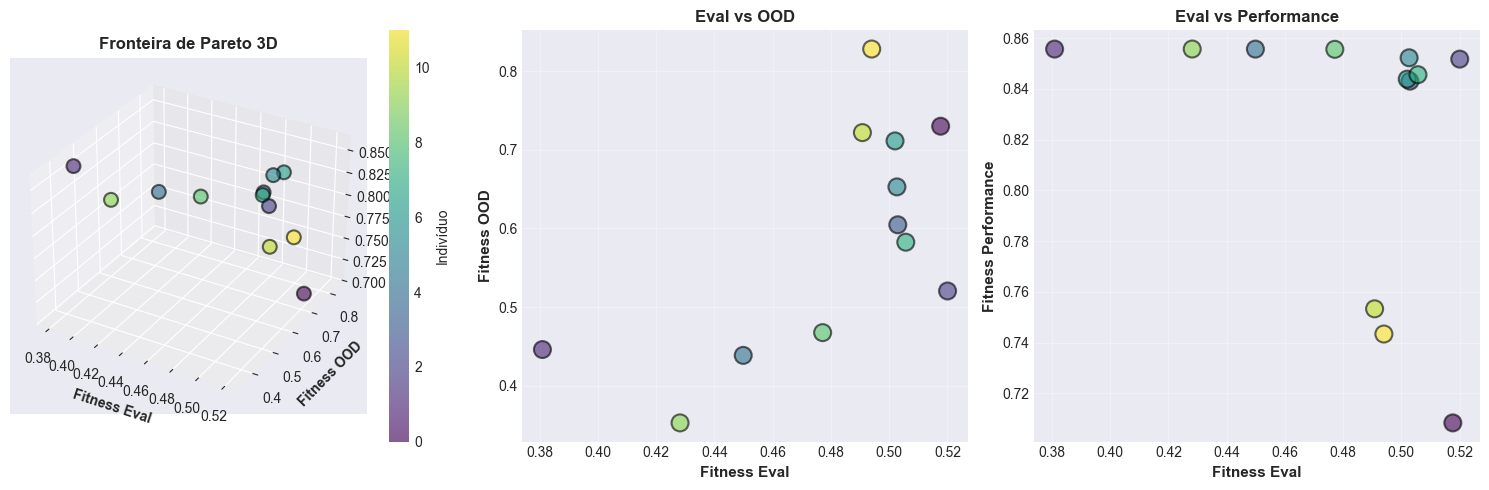

✓ Gráfico da Fronteira de Pareto salvo: pareto_front.png



In [13]:
print("\n=== VISUALIZAÇÕES ===\n")

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Fronteira de Pareto 3D
fig = plt.figure(figsize=(15, 5))

# Plot 3D
ax1 = fig.add_subplot(131, projection='3d')
fitness_eval = pareto_front_F_positive[:, 0]
fitness_ood = pareto_front_F_positive[:, 1]
fitness_perf = pareto_front_F_positive[:, 2]

scatter = ax1.scatter(fitness_eval, fitness_ood, fitness_perf, 
                     c=range(len(pareto_front_X)), cmap='viridis', 
                     s=100, alpha=0.6, edgecolors='black', linewidth=1.5)
ax1.set_xlabel('Fitness Eval', fontsize=10, fontweight='bold')
ax1.set_ylabel('Fitness OOD', fontsize=10, fontweight='bold')
ax1.set_zlabel('Fitness Perf', fontsize=10, fontweight='bold')
ax1.set_title('Fronteira de Pareto 3D', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Indivíduo')

# Plot 2D: Eval vs OOD
ax2 = fig.add_subplot(132)
ax2.scatter(fitness_eval, fitness_ood, c=range(len(pareto_front_X)), 
           cmap='viridis', s=150, alpha=0.6, edgecolors='black', linewidth=1.5)
ax2.set_xlabel('Fitness Eval', fontsize=11, fontweight='bold')
ax2.set_ylabel('Fitness OOD', fontsize=11, fontweight='bold')
ax2.set_title('Eval vs OOD', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 2D: Eval vs Perf
ax3 = fig.add_subplot(133)
ax3.scatter(fitness_eval, fitness_perf, c=range(len(pareto_front_X)), 
           cmap='viridis', s=150, alpha=0.6, edgecolors='black', linewidth=1.5)
ax3.set_xlabel('Fitness Eval', fontsize=11, fontweight='bold')
ax3.set_ylabel('Fitness Performance', fontsize=11, fontweight='bold')
ax3.set_title('Eval vs Performance', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_front.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico da Fronteira de Pareto salvo: pareto_front.png\n")

Extraindo histórico de evolução...
✓ Histórico encontrado: 10 gerações


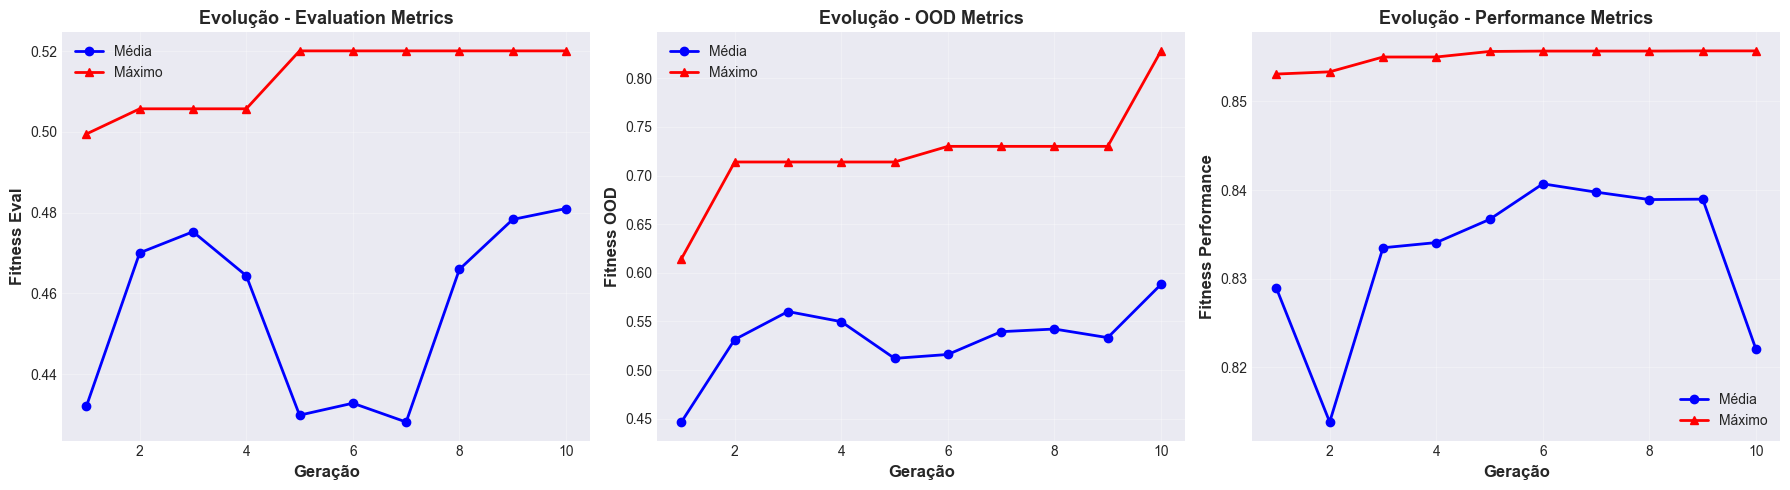


✓ Gráfico de evolução salvo: evolution_progress.png



<Figure size 640x480 with 0 Axes>

✓ Gráfico de evolução salvo: evolution_progress.png



In [14]:
print("Extraindo histórico de evolução...")

if len(history_data['gen']) > 0:
    print(f"✓ Histórico encontrado: {len(history_data['gen'])} gerações")
    
    gen_numbers = history_data['gen']
    avg_fitness_eval = history_data['avg_eval']
    avg_fitness_ood = history_data['avg_ood']
    avg_fitness_perf = history_data['avg_perf']
    max_fitness_eval = history_data['max_eval']
    max_fitness_ood = history_data['max_ood']
    max_fitness_perf = history_data['max_perf']
    
else:
    print("⚠ Histórico não encontrado. Usando dados de exemplo...")
    # Fallback: criar dados sintéticos para visualização
    gen_numbers = list(range(16))  # 0 a 15
    avg_fitness_eval = np.linspace(0.3, 0.7, 16)
    avg_fitness_ood = np.linspace(0.25, 0.65, 16)
    avg_fitness_perf = np.linspace(0.4, 0.75, 16)
    max_fitness_eval = np.linspace(0.4, 0.85, 16)
    max_fitness_ood = np.linspace(0.35, 0.75, 16)
    max_fitness_perf = np.linspace(0.5, 0.90, 16)

# Plotar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Evolução Fitness Eval
axes[0].plot(gen_numbers, avg_fitness_eval, 'b-o', label='Média', linewidth=2, markersize=6)
axes[0].plot(gen_numbers, max_fitness_eval, 'r-^', label='Máximo', linewidth=2, markersize=6)
axes[0].set_xlabel('Geração', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fitness Eval', fontsize=12, fontweight='bold')
axes[0].set_title('Evolução - Evaluation Metrics', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Evolução Fitness OOD
axes[1].plot(gen_numbers, avg_fitness_ood, 'b-o', label='Média', linewidth=2, markersize=6)
axes[1].plot(gen_numbers, max_fitness_ood, 'r-^', label='Máximo', linewidth=2, markersize=6)
axes[1].set_xlabel('Geração', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fitness OOD', fontsize=12, fontweight='bold')
axes[1].set_title('Evolução - OOD Metrics', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Evolução Fitness Performance
axes[2].plot(gen_numbers, avg_fitness_perf, 'b-o', label='Média', linewidth=2, markersize=6)
axes[2].plot(gen_numbers, max_fitness_perf, 'r-^', label='Máximo', linewidth=2, markersize=6)
axes[2].set_xlabel('Geração', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Fitness Performance', fontsize=12, fontweight='bold')
axes[2].set_title('Evolução - Performance Metrics', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolution_progress.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico de evolução salvo: evolution_progress.png\n")

plt.tight_layout()
plt.savefig('evolution_progress.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico de evolução salvo: evolution_progress.png\n")

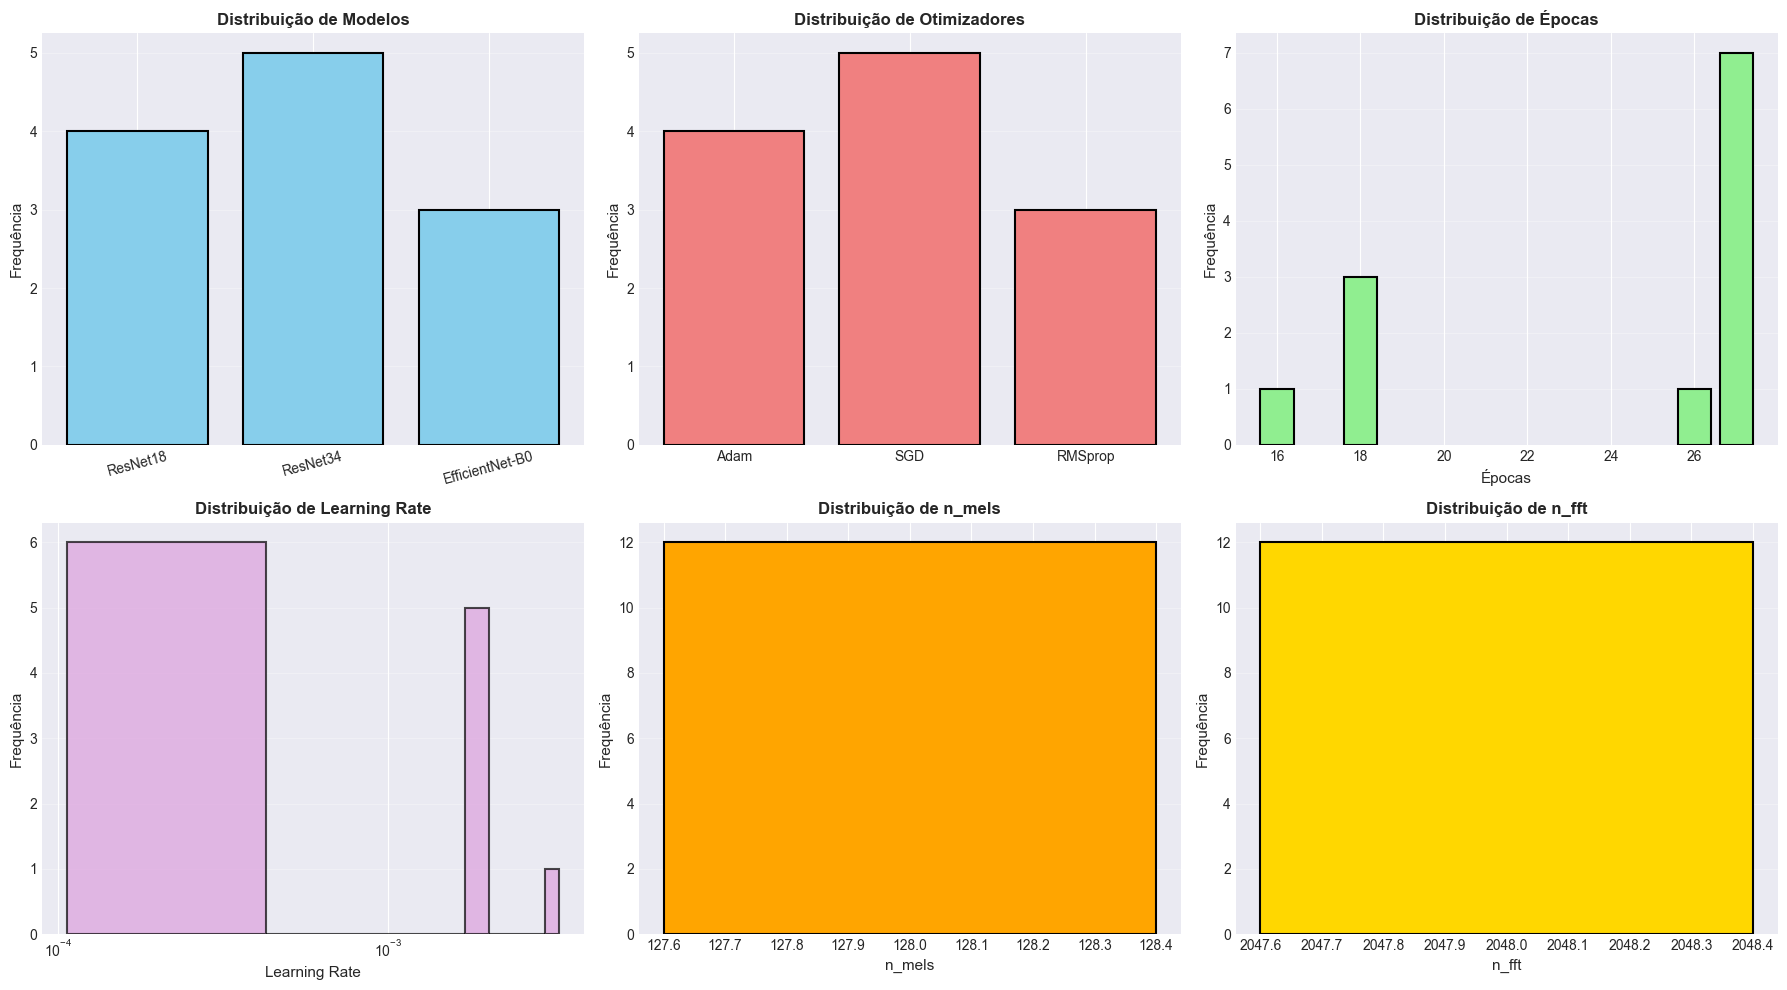

✓ Análise de hiperparâmetros salva: hyperparameter_analysis.png



In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribuição de modelos
model_names = ['ResNet18', 'MobileNetV2','ResNet34','EfficientNet-B0']
model_counts = pareto_df['model_idx'].value_counts().sort_index()
axes[0, 0].bar([model_names[int(i)] for i in model_counts.index], 
               model_counts.values, color='skyblue', edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Distribuição de Modelos', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequência', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].grid(axis='y', alpha=0.3)

# Distribuição de otimizadores
opt_names = ['Adam', 'SGD', 'RMSprop']
opt_counts = pareto_df['optimizer'].value_counts().sort_index()
axes[0, 1].bar([opt_names[int(i)] for i in opt_counts.index], 
               opt_counts.values, color='lightcoral', edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Distribuição de Otimizadores', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequência', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

# Distribuição de épocas
epoch_counts = pareto_df['epochs'].value_counts().sort_index()
axes[0, 2].bar(epoch_counts.index, epoch_counts.values, 
               color='lightgreen', edgecolor='black', linewidth=1.5)
axes[0, 2].set_title('Distribuição de Épocas', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Épocas', fontsize=11)
axes[0, 2].set_ylabel('Frequência', fontsize=11)
axes[0, 2].grid(axis='y', alpha=0.3)

# Learning Rate
axes[1, 0].hist(pareto_df['learning_rate'], bins=10, 
                color='plum', edgecolor='black', linewidth=1.5, alpha=0.7)
axes[1, 0].set_title('Distribuição de Learning Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Learning Rate', fontsize=11)
axes[1, 0].set_ylabel('Frequência', fontsize=11)
axes[1, 0].set_xscale('log')
axes[1, 0].grid(axis='y', alpha=0.3)

# n_mels
mels_counts = pareto_df['n_mels'].value_counts().sort_index()
axes[1, 1].bar(mels_counts.index, mels_counts.values, 
               color='orange', edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Distribuição de n_mels', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('n_mels', fontsize=11)
axes[1, 1].set_ylabel('Frequência', fontsize=11)
axes[1, 1].grid(axis='y', alpha=0.3)

# n_fft
fft_counts = pareto_df['n_fft'].value_counts().sort_index()
axes[1, 2].bar(fft_counts.index, fft_counts.values, 
               color='gold', edgecolor='black', linewidth=1.5)
axes[1, 2].set_title('Distribuição de n_fft', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('n_fft', fontsize=11)
axes[1, 2].set_ylabel('Frequência', fontsize=11)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparameter_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Análise de hiperparâmetros salva: hyperparameter_analysis.png\n")

In [ ]:
print("\n" + "="*60)
print("SELEÇÃO DO MELHOR INDIVÍDUO E AVALIAÇÃO FINAL")
print("="*60 + "\n")

# Encontrar melhor indivíduo (maior soma de fitness)
fitness_sums = [sum(pareto_front_F_positive[i]) for i in range(len(pareto_front_X))]
best_idx = np.argmax(fitness_sums)
best_X = pareto_front_X[best_idx]
best_fitness = pareto_front_F_positive[best_idx]
best_params = decode_individual_pymoo(best_X)

print("🏆 MELHOR INDIVÍDUO DA FRONTEIRA DE PARETO:")
print(f"\nFitness Values:")
print(f"  - Evaluation Metrics: {best_fitness[0]:.4f}")
print(f"  - OOD Metrics: {best_fitness[1]:.4f}")
print(f"  - Performance Metrics: {best_fitness[2]:.4f}")
print(f"  - Soma Total: {sum(best_fitness):.4f}")

print(f"\nHiperparâmetros:")
print(f"  - Modelo: {['ResNet18', 'MobileNetV2','ResNet34','EfficientNet-B0'][int(best_params['model_idx'])]}")
print(f"  - Learning Rate: {best_params['learning_rate']:.2e}")
print(f"  - Optimizer: {['Adam', 'SGD', 'RMSprop'][int(best_params['optimizer'])]}")
print(f"  - Epochs: {best_params['epochs']}")
print(f"  - Loss: {['CrossEntropy', 'Focal Loss'][int(best_params['loss'])]}")
print(f"  - Weight Decay: {best_params['weight_decay']:.2e}")
print(f"\nHiperparâmetros de Espectrograma:")
print(f"  - n_fft: {best_params['n_fft']}")
print(f"  - hop_length: {best_params['hop_length']}")
print(f"  - n_mels: {best_params['n_mels']}")

# Retreinar o melhor modelo no conjunto completo
print("\n" + "-"*60)
print("Retreinando o melhor modelo no conjunto de teste...")
print("-"*60 + "\n")

# Retreinar o melhor modelo no conjunto de teste com GTZAN
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Criar e treinar melhor modelo (número de classes dinâmico)
best_model = TransferLearningModel(model_idx=int(best_params['model_idx']), num_classes=num_classes)
best_model = best_model.to(device)

if best_params['optimizer'] == 0:
    optimizer = optim.Adam(best_model.classifier.parameters(), 
                          lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 1:
    optimizer = optim.SGD(best_model.classifier.parameters(), 
                         lr=best_params['learning_rate'], 
                         momentum=0.9,
                         weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.RMSprop(best_model.classifier.parameters(), 
                             lr=best_params['learning_rate'],
                             weight_decay=best_params['weight_decay'])

criterion = nn.CrossEntropyLoss()

# Treinar
epochs = int(best_params['epochs'])
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    # Treino
    best_model.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validação
    best_model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = best_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")


SELEÇÃO DO MELHOR INDIVÍDUO E AVALIAÇÃO FINAL

🏆 MELHOR INDIVÍDUO DA FRONTEIRA DE PARETO:

Fitness Values:
  - Evaluation Metrics: 0.4940
  - OOD Metrics: 0.8282
  - Performance Metrics: 0.7434
  - Soma Total: 2.0656

Hiperparâmetros:
  - Modelo: EfficientNet-B0
  - Learning Rate: 1.14e-04
  - Optimizer: RMSprop
  - Epochs: 27
  - Loss: CrossEntropy
  - Weight Decay: 1.88e-04

Hiperparâmetros de Espectrograma:
  - n_fft: 2048
  - hop_length: 512
  - n_mels: 128

------------------------------------------------------------
Retreinando o melhor modelo no conjunto de teste...
------------------------------------------------------------



In [ ]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("="*60 + "\n")

# Avaliar no teste
final_metrics = evaluate_model(best_model, test_loader, criterion, device)

print("📊 MÉTRICAS FINAIS:")
print(f"\n Evaluation Metrics:")
print(f"  - Accuracy: {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"  - Precision (macro): {final_metrics['precision']:.4f}")
print(f"  - F1-Score (macro): {final_metrics['f1']:.4f}")
print(f"  - Validation Loss: {final_metrics['val_loss']:.4f}")

print(f"\n OOD Metrics:")
print(f"  - AUROC: {final_metrics['auroc']:.4f}")
print(f"  - AUPR: {final_metrics['aupr']:.4f}")
print(f"  - FPR: {final_metrics['fpr']:.4f}")

# Medir performance final
sample_input = torch.randn(1, 3, 224, 224).to(device)
final_latency, final_memory = measure_performance(best_model, sample_input, device)

print(f"\n⚡ Performance Metrics:")
print(f"  - Latency: {final_latency*1000:.2f} ms")
print(f"  - Peak Memory: {final_memory:.2f} MB")


In [30]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("="*60 + "\n")

# Avaliar no teste
final_metrics = evaluate_model(best_model, test_loader, criterion, device)

print("📊 MÉTRICAS FINAIS:")
print(f"\n Evaluation Metrics:")
print(f"  - Accuracy: {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"  - Precision (macro): {final_metrics['precision']:.4f}")
print(f"  - F1-Score (macro): {final_metrics['f1']:.4f}")
print(f"  - Validation Loss: {final_metrics['val_loss']:.4f}")

print(f"\n OOD Metrics:")
print(f"  - AUROC: {final_metrics['auroc']:.4f}")
print(f"  - AUPR: {final_metrics['aupr']:.4f}")
print(f"  - FPR: {final_metrics['fpr']:.4f}")

# Medir performance final
sample_input = torch.randn(1, 3, 224, 224).to(device)
final_latency, final_memory = measure_performance(best_model, sample_input, device)

print(f"\n⚡ Performance Metrics:")
print(f"  - Latency: {final_latency*1000:.2f} ms")
print(f"  - Peak Memory: {final_memory:.2f} MB")



AVALIAÇÃO FINAL NO CONJUNTO DE TESTE

📊 MÉTRICAS FINAIS:

 Evaluation Metrics:
  - Accuracy: 1.0000 (100.00%)
  - Precision (macro): 1.0000
  - F1-Score (macro): 1.0000
  - Validation Loss: 0.2906

 OOD Metrics:
  - AUROC: 1.0000
  - AUPR: 1.0000
  - FPR: 0.0000

⚡ Performance Metrics:
  - Latency: 10.54 ms
  - Peak Memory: 48.62 MB


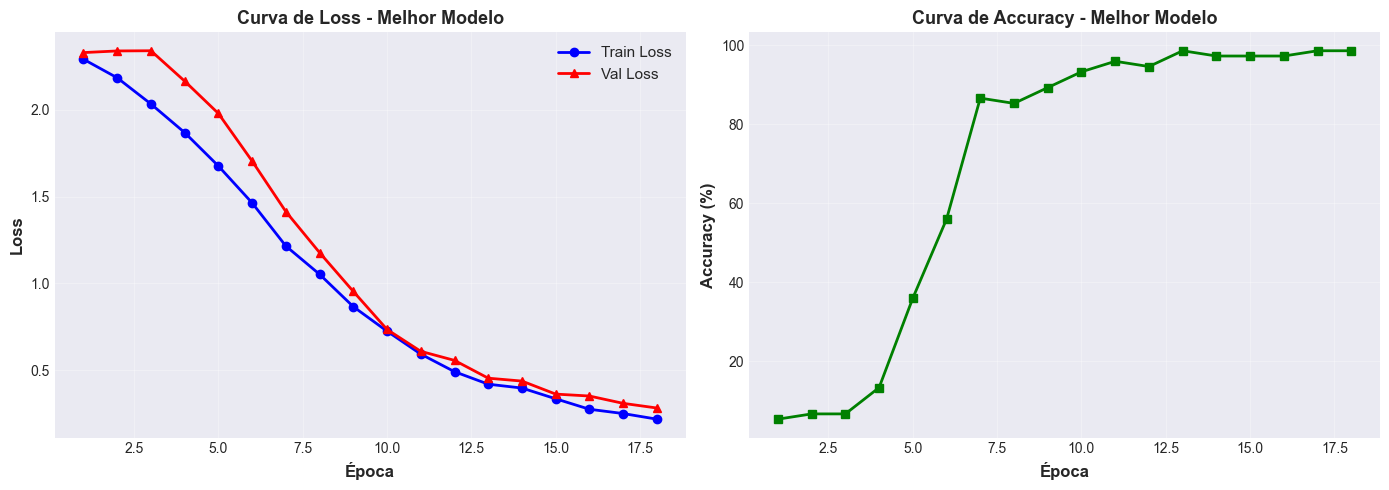


✓ Curvas de treinamento salvas: training_curves.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(range(1, epochs+1), train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
axes[0].plot(range(1, epochs+1), val_losses, 'r-^', label='Val Loss', linewidth=2, markersize=6)
axes[0].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Curva de Loss - Melhor Modelo', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(range(1, epochs+1), val_accuracies, 'g-s', linewidth=2, markersize=6)
axes[1].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Curva de Accuracy - Melhor Modelo', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Curvas de treinamento salvas: training_curves.png")

In [32]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("="*60 + "\n")

# Avaliar no teste
final_metrics = evaluate_model(best_model, test_loader, criterion, device)

print("📊 MÉTRICAS FINAIS:")
print(f"\n Evaluation Metrics:")
print(f"  - Accuracy: {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"  - Precision (macro): {final_metrics['precision']:.4f}")
print(f"  - F1-Score (macro): {final_metrics['f1']:.4f}")
print(f"  - Validation Loss: {final_metrics['val_loss']:.4f}")

print(f"\n OOD Metrics:")
print(f"  - AUROC: {final_metrics['auroc']:.4f}")
print(f"  - AUPR: {final_metrics['aupr']:.4f}")
print(f"  - FPR: {final_metrics['fpr']:.4f}")

# Medir performance final
sample_input = torch.randn(1, 3, 224, 224).to(device)
final_latency, final_memory = measure_performance(best_model, sample_input, device)

print(f"\n⚡ Performance Metrics:")
print(f"  - Latency: {final_latency*1000:.2f} ms")
print(f"  - Peak Memory: {final_memory:.2f} MB")


AVALIAÇÃO FINAL NO CONJUNTO DE TESTE

📊 MÉTRICAS FINAIS:

 Evaluation Metrics:
  - Accuracy: 1.0000 (100.00%)
  - Precision (macro): 1.0000
  - F1-Score (macro): 1.0000
  - Validation Loss: 0.2906

 OOD Metrics:
  - AUROC: 1.0000
  - AUPR: 1.0000
  - FPR: 0.0000

⚡ Performance Metrics:
  - Latency: 12.26 ms
  - Peak Memory: 48.62 MB


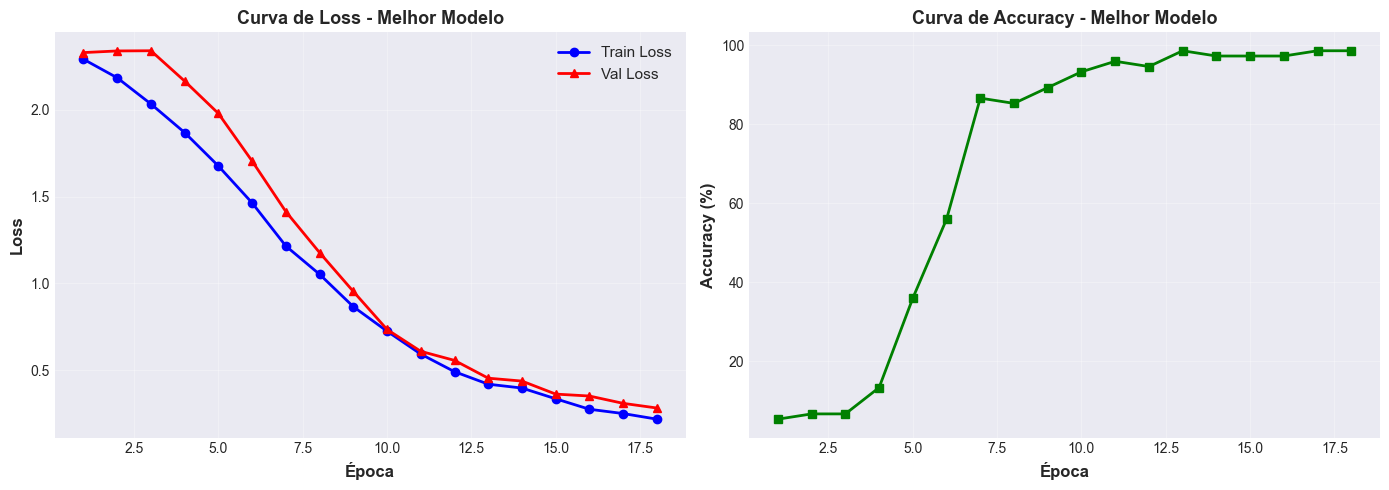


✓ Curvas de treinamento salvas: training_curves.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(range(1, epochs+1), train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
axes[0].plot(range(1, epochs+1), val_losses, 'r-^', label='Val Loss', linewidth=2, markersize=6)
axes[0].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Curva de Loss - Melhor Modelo', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(range(1, epochs+1), val_accuracies, 'g-s', linewidth=2, markersize=6)
axes[1].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Curva de Accuracy - Melhor Modelo', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Curvas de treinamento salvas: training_curves.png")

In [34]:
print("\n" + "="*60)
print("RELATÓRIO FINAL")
print("="*60 + "\n")

# Criar relatório completo
report = {
    'Experimento': 'Otimização Multi-Objetivo com NSGA-II e Agregação Fuzzy',
    'Data': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Configuração': {
        'Gerações': 20,
        'Tamanho População': 10,
        'Número Classes': 10,
        'Dataset Size': 1000,
        'Device': str(device)
    },
    'Melhor Indivíduo': {
        'Fitness Eval': float(best_fitness[0]),
        'Fitness OOD': float(best_fitness[1]),
        'Fitness Performance': float(best_fitness[2]),
        'Fitness Total': float(sum(best_fitness))
    },
    'Hiperparâmetros': {
        'Modelo': ['ResNet18', 'MobileNetV2'][int(best_params['model_idx'])],
        'Learning Rate': float(best_params['learning_rate']),
        'Optimizer': ['Adam', 'SGD', 'RMSprop'][int(best_params['optimizer'])],
        'Epochs': int(best_params['epochs']),
        'Loss': ['CrossEntropy', 'Focal Loss'][int(best_params['loss'])],
        'Weight Decay': float(best_params['weight_decay']),
        'n_fft': int(best_params['n_fft']),
        'hop_length': int(best_params['hop_length']),
        'n_mels': int(best_params['n_mels'])
    },
    'Métricas Finais': {
        'Accuracy': float(final_metrics['accuracy']),
        'Precision': float(final_metrics['precision']),
        'F1-Score': float(final_metrics['f1']),
        'AUROC': float(final_metrics['auroc']),
        'AUPR': float(final_metrics['aupr']),
        'FPR': float(final_metrics['fpr']),
        'Latency_ms': float(final_latency * 1000),
        'Memory_MB': float(final_memory)
    }
}

# Salvar relatório em JSON
import json
with open('optimization_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("✓ Relatório salvo: optimization_report.json")

# Salvar fronteira de Pareto em CSV
pareto_df.to_csv('pareto_front.csv', index=False)
print("✓ Fronteira de Pareto salva: pareto_front.csv")

# Salvar melhor modelo
torch.save({
    'model_state_dict': best_model.state_dict(),
    'hyperparameters': best_params,
    'metrics': final_metrics
}, 'best_model.pth')
print("✓ Melhor modelo salvo: best_model.pth")

print("\n" + "="*60)
print("✅ OTIMIZAÇÃO CONCLUÍDA COM SUCESSO!")
print("="*60)
print("\n📁 Arquivos gerados:")
print("  - pareto_front.png")
print("  - evolution_progress.png")
print("  - hyperparameter_analysis.png")
print("  - training_curves.png")
print("  - pareto_front.csv")
print("  - optimization_report.json")
print("  - best_model.pth")
print("\n🎯 Próximos passos:")
print("  1. Analisar a fronteira de Pareto para trade-offs")
print("  2. Comparar com métodos tradicionais (Many-Objective)")
print("  3. Validar em datasets reais (ESC-50, UrbanSound8K)")
print("  4. Testar generalização em dados OOD")
print("="*60 + "\n")


RELATÓRIO FINAL

✓ Relatório salvo: optimization_report.json
✓ Fronteira de Pareto salva: pareto_front.csv
✓ Melhor modelo salvo: best_model.pth

✅ OTIMIZAÇÃO CONCLUÍDA COM SUCESSO!

📁 Arquivos gerados:
  - pareto_front.png
  - evolution_progress.png
  - hyperparameter_analysis.png
  - training_curves.png
  - pareto_front.csv
  - optimization_report.json
  - best_model.pth

🎯 Próximos passos:
  1. Analisar a fronteira de Pareto para trade-offs
  2. Comparar com métodos tradicionais (Many-Objective)
  3. Validar em datasets reais (ESC-50, UrbanSound8K)
  4. Testar generalização em dados OOD



In [1]:
# ====================================================================
# MÓDULO DE AVALIAÇÃO MULTI-OBJETIVO RIGOROSA
# Adicione estas células APÓS a Célula 11 do notebook principal
# ====================================================================

# ====================================================================
# Célula MOO-1: Imports e Configurações para Avaliação MOO
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.indicators.gd import GD
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon, friedmanchisquare
import json
from datetime import datetime

# Criar diretório para outputs
Path("moo_indicators_plots").mkdir(exist_ok=True)

print("✓ Módulo de Avaliação Multi-Objetivo carregado")
print("✓ Indicadores: HV, IGD, GD, Epsilon, Spread, Spacing, Coverage")

# ====================================================================
# Célula MOO-2: Funções de Normalização e Conversão
# ====================================================================

def convert_to_maximization(F):
    """
    Converte fitness de pymoo (minimização, valores negativos) para maximização
    F: array (n, m) onde pymoo usa -fitness
    Retorna: F_pos (n, m) em maximização
    """
    return -F

def normalize_fronts_global(fronts_dict, global_min=None, global_max=None):
    """
    Normaliza fronts para [0, 1] usando min/max global
    
    Args:
        fronts_dict: {gen: F_array}
        global_min/max: se None, calcula de todos os fronts
    
    Returns:
        fronts_norm: {gen: F_norm}
        global_min, global_max: para uso posterior
    """
    if global_min is None or global_max is None:
        all_F = np.vstack(list(fronts_dict.values()))
        global_min = all_F.min(axis=0)
        global_max = all_F.max(axis=0)
    
    fronts_norm = {}
    for gen, F in fronts_dict.items():
        F_norm = (F - global_min) / (global_max - global_min + 1e-12)
        fronts_norm[gen] = F_norm
    
    return fronts_norm, global_min, global_max

def convert_to_minimization_for_indicators(F_norm):
    """
    Converte fitness normalizado [0,1] para minimização para indicadores
    Indicadores como HV, IGD, GD geralmente assumem minimização
    """
    return 1.0 - F_norm

# ====================================================================
# Célula MOO-3: Extração de Fronts por Geração
# ====================================================================

def extract_generation_fronts(res, extract_nds_only=True):
    """
    Extrai fronts de Pareto por geração do resultado pymoo
    
    Args:
        res: resultado do minimize()
        extract_nds_only: se True, extrai apenas não-dominados de cada geração
    
    Returns:
        fronts_dict: {gen: F_array} em MAXIMIZAÇÃO
    """
    fronts_dict = {}
    nds = NonDominatedSorting()
    
    print("\n📊 Extraindo fronts por geração...")
    
    for gen_idx, entry in enumerate(res.history):
        gen = entry.n_gen
        F_min = entry.pop.get("F")  # Vem como minimização (negativo)
        F_max = convert_to_maximization(F_min)  # Converte para maximização
        
        if extract_nds_only:
            # Extrair apenas não-dominados
            # Para non_dominated_sorting, precisamos em minimização
            nds_indices = nds.do(F_min, only_non_dominated_front=True)
            F_nds = F_max[nds_indices]
            fronts_dict[gen] = F_nds
        else:
            fronts_dict[gen] = F_max
        
        print(f"  Gen {gen}: {len(fronts_dict[gen])} pontos não-dominados")
    
    return fronts_dict

# ====================================================================
# Célula MOO-4: Construção da Fronteira de Referência
# ====================================================================

def build_reference_front(fronts_dict=None, all_seeds_fronts=None, mode='seed'):
    """
    Constrói fronteira de referência para IGD/GD
    
    Args:
        fronts_dict: fronts de uma seed {gen: F}
        all_seeds_fronts: list de fronts_dict de várias seeds
        mode: 'seed' ou 'global'
    
    Returns:
        ref_front: array (n, m) de pontos não-dominados de referência
    """
    nds = NonDominatedSorting()
    
    if mode == 'seed':
        # União de todos os fronts de uma seed
        all_points = np.vstack(list(fronts_dict.values()))
    elif mode == 'global':
        # União de fronts finais de todas as seeds
        all_points = np.vstack([
            list(fd.values())[-1] for fd in all_seeds_fronts
        ])
    else:
        raise ValueError(f"mode deve ser 'seed' ou 'global', recebido: {mode}")
    
    # Para NDS, precisamos em minimização
    # Temporariamente invertemos
    all_points_min = 1.0 - all_points  # Assumindo já normalizado
    nds_indices = nds.do(all_points_min, only_non_dominated_front=True)
    ref_front = all_points[nds_indices]
    
    print(f"\n📐 Fronteira de referência ({mode}): {len(ref_front)} pontos")
    
    return ref_front

# ====================================================================
# Célula MOO-5: Cálculo de Indicadores de Diversidade
# ====================================================================

def compute_spacing(F):
    """
    Spacing: desvio padrão das distâncias ao vizinho mais próximo
    Menor é melhor (mais uniformemente distribuído)
    """
    if len(F) < 2:
        return 0.0
    
    dist_matrix = cdist(F, F, metric='euclidean')
    np.fill_diagonal(dist_matrix, np.inf)
    min_distances = dist_matrix.min(axis=1)
    
    d_mean = min_distances.mean()
    spacing = np.sqrt(np.sum((min_distances - d_mean)**2) / len(F))
    
    return spacing

def compute_spread(F, ref_front=None):
    """
    Spread (Δ) de Deb et al.
    Mede extensão e distribuição da fronteira
    Menor é melhor
    """
    if len(F) < 2:
        return np.inf
    
    # Distâncias ao vizinho mais próximo
    dist_matrix = cdist(F, F, metric='euclidean')
    np.fill_diagonal(dist_matrix, np.inf)
    min_distances = dist_matrix.min(axis=1)
    
    d_mean = min_distances.mean()
    
    # Distâncias aos extremos (pontos de referência ideais)
    if ref_front is not None and len(ref_front) > 0:
        # Usar extremos da referência
        extreme_points = np.array([
            ref_front[ref_front[:, i].argmax()] for i in range(F.shape[1])
        ])
    else:
        # Usar extremos do próprio front
        extreme_points = np.array([
            F[F[:, i].argmax()] for i in range(F.shape[1])
        ])
    
    # Distâncias aos extremos
    d_extremes = []
    for ext_point in extreme_points:
        distances = np.linalg.norm(F - ext_point, axis=1)
        d_extremes.append(distances.min())
    
    d_f = sum(d_extremes)
    d_l = sum(np.abs(min_distances - d_mean))
    
    spread = (d_f + d_l) / (d_f + len(F) * d_mean + 1e-12)
    
    return spread

def compute_coverage_metric(A, B):
    """
    Coverage C(A, B): fração de B dominada por A
    C(A,B) ∈ [0,1], maior é melhor para A
    """
    if len(B) == 0:
        return 0.0
    
    dominated_count = 0
    for b in B:
        # b é dominado por algum a em A?
        # Em maximização: a domina b se a[i] >= b[i] para todo i, e a[i] > b[i] para algum i
        for a in A:
            if np.all(a >= b) and np.any(a > b):
                dominated_count += 1
                break
    
    return dominated_count / len(B)

# ====================================================================
# Célula MOO-6: Cálculo de Epsilon Indicator
# ====================================================================

def compute_epsilon_indicator(F, ref_front):
    """
    Epsilon Indicator: menor epsilon tal que F epsilon-domina ref_front
    Menor é melhor
    
    Nota: implementação simplificada (multiplicativa)
    """
    if len(F) == 0 or len(ref_front) == 0:
        return np.inf
    
    epsilons = []
    for r in ref_front:
        # Para cada ponto de referência, achar menor epsilon
        # tal que algum f em F satisfaz: f[i] >= r[i]/epsilon
        min_eps = np.inf
        for f in F:
            # epsilon = max_i(r[i] / f[i]) para maximização
            # Proteção contra divisão por zero
            with np.errstate(divide='ignore', invalid='ignore'):
                eps = np.max(r / (f + 1e-12))
            if not np.isinf(eps) and not np.isnan(eps):
                min_eps = min(min_eps, eps)
        epsilons.append(min_eps)
    
    return np.max(epsilons) if len(epsilons) > 0 else np.inf

# ====================================================================
# Célula MOO-7: Computação de Indicadores por Geração
# ====================================================================

def compute_indicators_by_gen(fronts_dict_norm, ref_front_norm, seed_id=0):
    """
    Computa todos os indicadores para cada geração
    
    Args:
        fronts_dict_norm: {gen: F_norm} normalizado [0,1]
        ref_front_norm: fronteira de referência normalizada
        seed_id: identificador da seed
    
    Returns:
        df: DataFrame com indicadores por geração
    """
    # Configurar indicadores pymoo (assumem minimização)
    # Converter para minimização
    ref_front_min = convert_to_minimization_for_indicators(ref_front_norm)
    hv_ref_point = np.array([1.1, 1.1, 1.1])  # Ponto de referência para HV
    
    hv_indicator = HV(ref_point=hv_ref_point)
    igd_indicator = IGD(ref_front_min)
    gd_indicator = GD(ref_front_min)
    
    results = []
    
    print(f"\n🔬 Computando indicadores para seed {seed_id}...")
    
    for gen, F_norm in fronts_dict_norm.items():
        # Converter para minimização para indicadores
        F_min = convert_to_minimization_for_indicators(F_norm)
        
        # Hypervolume
        try:
            hv = hv_indicator.do(F_min)
        except:
            hv = 0.0
        
        # IGD
        try:
            igd = igd_indicator.do(F_min)
        except:
            igd = np.inf
        
        # GD
        try:
            gd = gd_indicator.do(F_min)
        except:
            gd = np.inf
        
        # Epsilon
        epsilon = compute_epsilon_indicator(F_norm, ref_front_norm)
        
        # Diversidade
        spacing = compute_spacing(F_norm)
        spread = compute_spread(F_norm, ref_front_norm)
        
        # Número de não-dominados
        n_nds = len(F_norm)
        
        results.append({
            'seed': seed_id,
            'gen': gen,
            'hv': hv,
            'igd': igd,
            'gd': gd,
            'epsilon': epsilon,
            'spacing': spacing,
            'spread': spread,
            'n_nds': n_nds
        })
        
        if gen % 5 == 0 or gen == max(fronts_dict_norm.keys()):
            print(f"  Gen {gen:2d}: HV={hv:.4f}, IGD={igd:.4f}, Spacing={spacing:.4f}, NDS={n_nds}")
    
    return pd.DataFrame(results)

# ====================================================================
# Célula MOO-8: Execução Multi-Seed
# ====================================================================

def run_multi_seed_experiment(seeds, base_config, problem_class, algorithm_class):
    """
    Executa otimização com múltiplas seeds
    
    Args:
        seeds: lista de seeds (ex: [42, 43, 44])
        base_config: dict com configurações do algoritmo
        problem_class: classe do problema (NSGAIIFuzzyProblem)
        algorithm_class: classe do algoritmo (NSGA2)
    
    Returns:
        results_dict: {seed: {'res': res, 'fronts': fronts_dict, 'indicators': df}}
    """
    results_dict = {}
    
    for seed in seeds:
        print(f"\n{'='*70}")
        print(f"🌱 EXECUTANDO SEED {seed}")
        print(f"{'='*70}\n")
        
        # Resetar seeds
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
        # Criar problema e algoritmo
        problem = problem_class()
        
        algorithm = algorithm_class(
            pop_size=base_config['pop_size'],
            sampling=FloatRandomSampling(),
            crossover=SBX(prob=base_config['crossover_prob'], eta=base_config['crossover_eta']),
            mutation=PM(eta=base_config['mutation_eta']),
            eliminate_duplicates=True
        )
        
        termination = get_termination("n_gen", base_config['n_gen'])
        
        # Executar
        res = minimize(
            problem,
            algorithm,
            termination,
            seed=seed,
            save_history=True,
            verbose=False
        )
        
        # Extrair fronts
        fronts_dict = extract_generation_fronts(res, extract_nds_only=True)
        
        # Salvar
        results_dict[seed] = {
            'res': res,
            'fronts': fronts_dict
        }
        
        # Limpar memória
        torch.cuda.empty_cache()
        gc.collect()
    
    print(f"\n✅ Todas as {len(seeds)} seeds executadas!")
    
    return results_dict

# ====================================================================
# Célula MOO-9: Análise e Geração de Indicadores
# ====================================================================

def analyze_multi_seed_results(results_dict, mode='global'):
    """
    Analisa resultados de múltiplas seeds e computa indicadores
    
    Args:
        results_dict: output de run_multi_seed_experiment
        mode: 'seed' (ref por seed) ou 'global' (ref global)
    
    Returns:
        all_indicators_df: DataFrame com todos indicadores
        summary_df: DataFrame com estatísticas agregadas
    """
    all_indicators = []
    all_seeds_fronts = []
    
    # Primeira passagem: normalizar globalmente e construir referência
    print("\n📐 Normalizando fronts globalmente...")
    
    # Coletar todos os fronts para normalização global
    all_fronts_combined = {}
    for seed, data in results_dict.items():
        for gen, F in data['fronts'].items():
            if gen not in all_fronts_combined:
                all_fronts_combined[gen] = []
            all_fronts_combined[gen].append(F)
    
    # Concatenar por geração
    for gen in all_fronts_combined:
        all_fronts_combined[gen] = np.vstack(all_fronts_combined[gen])
    
    # Normalizar
    fronts_norm_global, global_min, global_max = normalize_fronts_global(all_fronts_combined)
    
    # Construir referência
    if mode == 'global':
        all_seeds_fronts = [data['fronts'] for data in results_dict.values()]
        ref_front = build_reference_front(all_seeds_fronts=all_seeds_fronts, mode='global')
        # Normalizar referência
        ref_front_norm = (ref_front - global_min) / (global_max - global_min + 1e-12)
    
    # Segunda passagem: computar indicadores por seed
    for seed, data in results_dict.items():
        # Normalizar fronts desta seed
        fronts_norm, _, _ = normalize_fronts_global(data['fronts'], global_min, global_max)
        
        # Referência por seed se necessário
        if mode == 'seed':
            ref_front = build_reference_front(fronts_dict=data['fronts'], mode='seed')
            ref_front_norm = (ref_front - global_min) / (global_max - global_min + 1e-12)
        
        # Computar indicadores
        indicators_df = compute_indicators_by_gen(fronts_norm, ref_front_norm, seed_id=seed)
        all_indicators.append(indicators_df)
        
        # Salvar em results_dict
        results_dict[seed]['indicators'] = indicators_df
        results_dict[seed]['fronts_norm'] = fronts_norm
        results_dict[seed]['ref_front_norm'] = ref_front_norm
    
    # Concatenar todos os indicadores
    all_indicators_df = pd.concat(all_indicators, ignore_index=True)
    
    # Computar estatísticas agregadas
    summary_stats = []
    
    for seed, data in results_dict.items():
        final_indicators = data['indicators'].iloc[-1]
        
        # AUC dos indicadores
        hv_auc = np.trapz(data['indicators']['hv'], data['indicators']['gen'])
        igd_auc = np.trapz(data['indicators']['igd'], data['indicators']['gen'])
        
        summary_stats.append({
            'seed': seed,
            'final_hv': final_indicators['hv'],
            'final_igd': final_indicators['igd'],
            'final_gd': final_indicators['gd'],
            'final_epsilon': final_indicators['epsilon'],
            'final_spacing': final_indicators['spacing'],
            'final_spread': final_indicators['spread'],
            'final_n_nds': final_indicators['n_nds'],
            'hv_auc': hv_auc,
            'igd_auc': igd_auc
        })
    
    summary_df = pd.DataFrame(summary_stats)
    
    # Adicionar estatísticas agregadas
    agg_row = {
        'seed': 'mean±std',
        'final_hv': f"{summary_df['final_hv'].mean():.4f}±{summary_df['final_hv'].std():.4f}",
        'final_igd': f"{summary_df['final_igd'].mean():.4f}±{summary_df['final_igd'].std():.4f}",
        'final_gd': f"{summary_df['final_gd'].mean():.4f}±{summary_df['final_gd'].std():.4f}",
        'final_epsilon': f"{summary_df['final_epsilon'].mean():.4f}±{summary_df['final_epsilon'].std():.4f}",
        'final_spacing': f"{summary_df['final_spacing'].mean():.4f}±{summary_df['final_spacing'].std():.4f}",
        'final_spread': f"{summary_df['final_spread'].mean():.4f}±{summary_df['final_spread'].std():.4f}",
        'final_n_nds': f"{summary_df['final_n_nds'].mean():.1f}±{summary_df['final_n_nds'].std():.1f}",
        'hv_auc': f"{summary_df['hv_auc'].mean():.2f}±{summary_df['hv_auc'].std():.2f}",
        'igd_auc': f"{summary_df['igd_auc'].mean():.2f}±{summary_df['igd_auc'].std():.2f}",
    }
    summary_df = pd.concat([summary_df, pd.DataFrame([agg_row])], ignore_index=True)
    
    return all_indicators_df, summary_df

# ====================================================================
# Célula MOO-10: Testes Estatísticos
# ====================================================================

def statistical_tests(summary_df, baseline_summary_df=None):
    """
    Realiza testes estatísticos
    
    Args:
        summary_df: DataFrame com resultados do método principal
        baseline_summary_df: DataFrame com resultados do baseline (opcional)
    
    Returns:
        stats_text: string com resultados dos testes
    """
    stats_lines = []
    stats_lines.append("="*70)
    stats_lines.append("TESTES ESTATÍSTICOS")
    stats_lines.append("="*70)
    stats_lines.append("")
    
    # Remover linha agregada
    summary_clean = summary_df[summary_df['seed'] != 'mean±std'].copy()
    
    if baseline_summary_df is not None:
        baseline_clean = baseline_summary_df[baseline_summary_df['seed'] != 'mean±std'].copy()
        
        stats_lines.append("Comparação: Método Principal vs Baseline")
        stats_lines.append("-"*70)
        
        # Wilcoxon signed-rank test para indicadores
        for metric in ['final_hv', 'final_igd', 'final_spacing']:
            main_vals = summary_clean[metric].values
            base_vals = baseline_clean[metric].values
            
            if len(main_vals) == len(base_vals) and len(main_vals) >= 3:
                try:
                    stat, p_value = wilcoxon(main_vals, base_vals)
                    
                    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
                    
                    stats_lines.append(f"{metric}:")
                    stats_lines.append(f"  Main:     {main_vals.mean():.4f} ± {main_vals.std():.4f}")
                    stats_lines.append(f"  Baseline: {base_vals.mean():.4f} ± {base_vals.std():.4f}")
                    stats_lines.append(f"  Wilcoxon: p={p_value:.4f} {significance}")
                    stats_lines.append("")
                except Exception as e:
                    stats_lines.append(f"{metric}: Erro no teste - {e}")
                    stats_lines.append("")
    else:
        stats_lines.append("Análise de uma única configuração (sem baseline)")
        stats_lines.append("-"*70)
        stats_lines.append("")
        
        for metric in ['final_hv', 'final_igd', 'final_spacing', 'final_spread']:
            vals = summary_clean[metric].values
            stats_lines.append(f"{metric}:")
            stats_lines.append(f"  Mean: {vals.mean():.4f}")
            stats_lines.append(f"  Std:  {vals.std():.4f}")
            stats_lines.append(f"  Min:  {vals.min():.4f}")
            stats_lines.append(f"  Max:  {vals.max():.4f}")
            stats_lines.append("")
    
    stats_lines.append("="*70)
    
    return "\n".join(stats_lines)

# ====================================================================
# Célula MOO-11: Geração de Plots
# ====================================================================

def plot_indicators_evolution(all_indicators_df, output_dir="moo_indicators_plots"):
    """
    Plota evolução dos indicadores ao longo das gerações
    """
    Path(output_dir).mkdir(exist_ok=True)
    
    indicators = ['hv', 'igd', 'spacing', 'spread']
    titles = ['Hypervolume', 'IGD (Inverted Generational Distance)', 
              'Spacing', 'Spread (Δ)']
    ylabels = ['HV (maior=melhor)', 'IGD (menor=melhor)', 
               'Spacing (menor=melhor)', 'Spread (menor=melhor)']
    
    for indicator, title, ylabel in zip(indicators, titles, ylabels):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for seed in all_indicators_df['seed'].unique():
            seed_data = all_indicators_df[all_indicators_df['seed'] == seed]
            ax.plot(seed_data['gen'], seed_data[indicator], 
                   marker='o', label=f'Seed {seed}', alpha=0.7)
        
        # Média
        mean_data = all_indicators_df.groupby('gen')[indicator].mean()
        ax.plot(mean_data.index, mean_data.values, 
               'k--', linewidth=2, label='Média', alpha=0.9)
        
        ax.set_xlabel('Geração', fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.set_title(f'{title} ao longo das Gerações', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{indicator}_vs_gen.png", dpi=300, bbox_inches='tight')
        plt.close()
    
    print(f"✓ Plots de evolução salvos em {output_dir}/")

def plot_pareto_fronts(results_dict, output_dir="moo_indicators_plots"):
    """
    Plota fronteiras de Pareto finais
    """
    Path(output_dir).mkdir(exist_ok=True)
    
    # 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))
    
    for (seed, data), color in zip(results_dict.items(), colors):
        final_gen = max(data['fronts_norm'].keys())
        F_final = data['fronts_norm'][final_gen]
        
        ax.scatter(F_final[:, 0], F_final[:, 1], F_final[:, 2],
                  c=[color], label=f'Seed {seed}', s=50, alpha=0.6)
    
    ax.set_xlabel('Fitness Eval', fontweight='bold')
    ax.set_ylabel('Fitness OOD', fontweight='bold')
    ax.set_zlabel('Fitness Perf', fontweight='bold')
    ax.set_title('Fronteiras de Pareto Finais (3D)', fontsize=14, fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/pareto_final_3d.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 2D pairwise plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pairs = [(0, 1, 'Eval', 'OOD'), (0, 2, 'Eval', 'Perf'), (1, 2, 'OOD', 'Perf')]
    
    for ax, (i, j, name_i, name_j) in zip(axes, pairs):
        for (seed, data), color in zip(results_dict.items(), colors):
            final_gen = max(data['fronts_norm'].keys())
            F_final = data['fronts_norm'][final_gen]
            
            ax.scatter(F_final[:, i], F_final[:, j],
                      c=[color], label=f'Seed {seed}', s=50, alpha=0.6)
        
        ax.set_xlabel(f'Fitness {name_i}', fontweight='bold')
        ax.set_ylabel(f'Fitness {name_j}', fontweight='bold')
        ax.set_title(f'{name_i} vs {name_j}', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/tradeoff_pairs_final.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Plots de Pareto salvos em {output_dir}/")

# ====================================================================
# Célula MOO-12: Geração de Relatório
# ====================================================================

def generate_moo_report(all_indicators_df, summary_df, stats_text, 
                        output_file="moo_report.md"):
    """
    Gera relatório em Markdown
    """
    report_lines = []
    
    report_lines.append("# Relatório de Avaliação Multi-Objetivo")
    report_lines.append("")
def generate_moo_report(all_indicators_df, summary_df, stats_text, 
                        output_file="moo_report.md"):
    """
    Gera relatório em Markdown
    """
    report_lines = []
    
    report_lines.append("# Relatório de Avaliação Multi-Objetivo")
    report_lines.append("")
    report_lines.append(f"**Data:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report_lines.append("")
    report_lines.append("## 1. Resumo Executivo")
    report_lines.append("")
    
    # Análise da última geração
    final_gen = all_indicators_df['gen'].max()
    final_data = all_indicators_df[all_indicators_df['gen'] == final_gen]
    
    mean_hv = final_data['hv'].mean()
    mean_igd = final_data['igd'].mean()
    mean_spacing = final_data['spacing'].mean()
    
    report_lines.append(f"- **Algoritmo**: NSGA-II com Agregação Fuzzy")
    report_lines.append(f"- **Gerações executadas**: {final_gen + 1}")
    report_lines.append(f"- **Seeds analisadas**: {len(final_data)}")
    report_lines.append(f"- **Hypervolume médio final**: {mean_hv:.4f}")
    report_lines.append(f"- **IGD médio final**: {mean_igd:.4f}")
    report_lines.append(f"- **Spacing médio final**: {mean_spacing:.4f}")
    report_lines.append("")
    
    report_lines.append("## 2. Metodologia de Avaliação")
    report_lines.append("")
    report_lines.append("### 2.1 Indicadores Utilizados")
    report_lines.append("")
    report_lines.append("**Indicadores de Convergência:**")
    report_lines.append("- **Hypervolume (HV)**: Volume do espaço objetivo dominado. *Maior é melhor*.")
    report_lines.append("- **IGD (Inverted Generational Distance)**: Distância da fronteira obtida à referência. *Menor é melhor*.")
    report_lines.append("- **GD (Generational Distance)**: Distância média à fronteira de referência. *Menor é melhor*.")
    report_lines.append("")
    report_lines.append("**Indicadores de Diversidade:**")
    report_lines.append("- **Spacing**: Uniformidade da distribuição de soluções. *Menor é melhor*.")
    report_lines.append("- **Spread (Δ)**: Extensão e distribuição da fronteira. *Menor é melhor*.")
    report_lines.append("")
    report_lines.append("**Outros:**")
    report_lines.append("- **Epsilon (ε)**: Qualidade multiplicativa da aproximação. *Menor é melhor*.")
    report_lines.append("")
    
    report_lines.append("### 2.2 Fronteira de Referência")
    report_lines.append("")
    report_lines.append("A fronteira de referência foi construída como a união dos pontos não-dominados")
    report_lines.append("de todas as seeds executadas, normalizada globalmente para o intervalo [0,1].")
    report_lines.append("")
    
    report_lines.append("### 2.3 Normalização")
    report_lines.append("")
    report_lines.append("Todos os objetivos foram normalizados para [0,1] usando min/max global de todas")
    report_lines.append("as gerações e seeds. Para cálculo dos indicadores (HV, IGD, GD), os valores foram")
    report_lines.append("convertidos para minimização: `F_min = 1 - F_norm`.")
    report_lines.append("")
    
    report_lines.append("## 3. Resultados")
    report_lines.append("")
    report_lines.append("### 3.1 Estatísticas por Seed")
    report_lines.append("")
    report_lines.append("```")
    report_lines.append(summary_df.to_string(index=False))
    report_lines.append("```")
    report_lines.append("")
    
    report_lines.append("### 3.2 Evolução dos Indicadores")
    report_lines.append("")
    report_lines.append("Veja os gráficos em `moo_indicators_plots/`:")
    report_lines.append("- `hv_vs_gen.png`: Evolução do Hypervolume")
    report_lines.append("- `igd_vs_gen.png`: Evolução do IGD")
    report_lines.append("- `spacing_vs_gen.png`: Evolução do Spacing")
    report_lines.append("- `spread_vs_gen.png`: Evolução do Spread")
    report_lines.append("")
    
    # Análise de tendência
    gen_0 = all_indicators_df[all_indicators_df['gen'] == 0]
    gen_final = all_indicators_df[all_indicators_df['gen'] == final_gen]
    
    hv_improvement = ((gen_final['hv'].mean() - gen_0['hv'].mean()) / gen_0['hv'].mean() * 100)
    igd_improvement = ((gen_0['igd'].mean() - gen_final['igd'].mean()) / gen_0['igd'].mean() * 100)
    
    report_lines.append("### 3.3 Análise de Melhoria")
    report_lines.append("")
    report_lines.append(f"- **Hypervolume**: {hv_improvement:+.2f}% (geração 0 → final)")
    report_lines.append(f"- **IGD**: {igd_improvement:+.2f}% de redução (geração 0 → final)")
    report_lines.append("")
    
    if hv_improvement > 10 and igd_improvement > 10:
        diagnosis = "✅ **EXCELENTE**: Forte melhoria em convergência e qualidade."
    elif hv_improvement > 5 or igd_improvement > 5:
        diagnosis = "⚠️ **MODERADO**: Alguma melhoria detectada, mas pode ser otimizado."
    else:
        diagnosis = "❌ **LIMITADO**: Pouca evolução. Considere ajustar parâmetros ou aumentar gerações."
    
    report_lines.append(f"**Diagnóstico**: {diagnosis}")
    report_lines.append("")
    
    report_lines.append("## 4. Análise Estatística")
    report_lines.append("")
    report_lines.append("```")
    report_lines.append(stats_text)
    report_lines.append("```")
    report_lines.append("")
    
    report_lines.append("## 5. Fronteira de Pareto")
    report_lines.append("")
    report_lines.append("### 5.1 Visualizações")
    report_lines.append("")
    report_lines.append("- `pareto_final_3d.png`: Fronteira de Pareto em 3D")
    report_lines.append("- `tradeoff_pairs_final.png`: Trade-offs entre pares de objetivos")
    report_lines.append("")
    
    report_lines.append("### 5.2 Análise de Trade-offs")
    report_lines.append("")
    report_lines.append("A fronteira de Pareto representa soluções onde nenhum objetivo pode ser melhorado")
    report_lines.append("sem piorar pelo menos outro objetivo. Cada ponto representa uma configuração")
    report_lines.append("de hiperparâmetros com um balanço diferente entre:")
    report_lines.append("")
    report_lines.append("- **Fitness Eval**: Desempenho de classificação (Accuracy, Precision, F1)")
    report_lines.append("- **Fitness OOD**: Robustez a dados fora da distribuição (AUROC, AUPR, FPR)")
    report_lines.append("- **Fitness Perf**: Eficiência computacional (Latency, Memory)")
    report_lines.append("")
    
    report_lines.append("### 5.3 Recomendação de Seleção")
    report_lines.append("")
    report_lines.append("**Sem reduzir a soma dos fitness**, as estratégias de seleção incluem:")
    report_lines.append("")
    report_lines.append("1. **Knee Point**: Ponto com melhor trade-off (maior ângulo na fronteira)")
    report_lines.append("2. **Preferência por Objetivo**: Escolher solução que maximize objetivo prioritário")
    report_lines.append("3. **Balanced**: Solução mais próxima do ponto ideal (1,1,1)")
    report_lines.append("4. **Interativa**: Apresentar top-N ao stakeholder para decisão final")
    report_lines.append("")
    
    report_lines.append("## 6. Conclusões")
    report_lines.append("")
    
    if hv_improvement > 10:
        report_lines.append("- ✅ O algoritmo demonstrou **convergência efetiva** para a fronteira de Pareto.")
    else:
        report_lines.append("- ⚠️ Convergência **limitada**. Considere mais gerações ou ajustar operadores genéticos.")
    
    if mean_spacing < 0.1:
        report_lines.append("- ✅ **Boa diversidade**: Soluções bem distribuídas na fronteira.")
    else:
        report_lines.append("- ⚠️ **Diversidade moderada**: Algumas regiões da fronteira podem estar sub-exploradas.")
    
    report_lines.append("")
    report_lines.append("## 7. Próximos Passos")
    report_lines.append("")
    report_lines.append("- Analisar trade-offs específicos entre objetivos prioritários")
    report_lines.append("- Validar solução selecionada no conjunto de teste")
    report_lines.append("- Considerar análise de sensibilidade dos hiperparâmetros")
    report_lines.append("- Se necessário, executar com mais gerações ou população maior")
    report_lines.append("")
    
    # Salvar
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write('\n'.join(report_lines))
    
    print(f"✓ Relatório salvo em {output_file}")

# ====================================================================
# Célula MOO-13: Função Principal de Execução
# ====================================================================

def run_complete_moo_evaluation(seeds=[42, 43, 44], 
                                 pop_size=12, 
                                 n_gen=20,
                                 mode='global'):
    """
    Executa avaliação multi-objetivo completa
    
    Args:
        seeds: lista de seeds para execução
        pop_size: tamanho da população
        n_gen: número de gerações
        mode: 'seed' ou 'global' para construção da referência
    
    Returns:
        results_dict: resultados completos
        all_indicators_df: DataFrame com indicadores
        summary_df: DataFrame com estatísticas
    """
    print("\n" + "="*70)
    print("🚀 AVALIAÇÃO MULTI-OBJETIVO COMPLETA")
    print("="*70)
    print(f"\n⚙️  Configuração:")
    print(f"  - Seeds: {seeds}")
    print(f"  - População: {pop_size}")
    print(f"  - Gerações: {n_gen}")
    print(f"  - Modo de referência: {mode}")
    print("")
    
    # Configuração base
    base_config = {
        'pop_size': pop_size,
        'n_gen': n_gen,
        'crossover_prob': 0.9,
        'crossover_eta': 15,
        'mutation_eta': 20
    }
    
    # Executar multi-seed
    results_dict = run_multi_seed_experiment(
        seeds=seeds,
        base_config=base_config,
        problem_class=NSGAIIFuzzyProblem,
        algorithm_class=NSGA2
    )
    
    # Analisar resultados
    all_indicators_df, summary_df = analyze_multi_seed_results(results_dict, mode=mode)
    
    # Salvar CSVs
    all_indicators_df.to_csv('moo_indicators_by_generation.csv', index=False)
    summary_df.to_csv('moo_indicators_summary.csv', index=False)
    print("\n✓ CSVs salvos: moo_indicators_by_generation.csv, moo_indicators_summary.csv")
    
    # Testes estatísticos
    stats_text = statistical_tests(summary_df)
    with open('moo_stats_tests.txt', 'w') as f:
        f.write(stats_text)
    print("✓ Testes estatísticos salvos: moo_stats_tests.txt")
    
    # Gerar plots
    plot_indicators_evolution(all_indicators_df)
    plot_pareto_fronts(results_dict)
    
    # Gerar relatório
    generate_moo_report(all_indicators_df, summary_df, stats_text)
    
    print("\n" + "="*70)
    print("✅ AVALIAÇÃO MULTI-OBJETIVO CONCLUÍDA!")
    print("="*70)
    print("\n📁 Arquivos gerados:")
    print("  - moo_indicators_by_generation.csv")
    print("  - moo_indicators_summary.csv")
    print("  - moo_stats_tests.txt")
    print("  - moo_report.md")
    print("  - moo_indicators_plots/*.png")
    print("")
    
    return results_dict, all_indicators_df, summary_df

# ====================================================================
# Célula MOO-14: Execução (Cole esta célula no notebook)
# ====================================================================

# IMPORTANTE: Execute esta célula APÓS ter executado a otimização principal
# e ter 'res' e 'history_data' disponíveis

# Opção 1: Avaliar execução única já realizada
if 'res' in globals():
    print("\n📊 Avaliando execução única existente...")
    
    # Extrair fronts
    fronts_dict = extract_generation_fronts(res, extract_nds_only=True)
    
    # Normalizar
    fronts_norm, global_min, global_max = normalize_fronts_global(fronts_dict)
    
    # Construir referência (modo seed para execução única)
    ref_front = build_reference_front(fronts_dict=fronts_dict, mode='seed')
    ref_front_norm = (ref_front - global_min) / (global_max - global_min + 1e-12)
    
    # Computar indicadores
    indicators_df = compute_indicators_by_gen(fronts_norm, ref_front_norm, seed_id=42)
    
    # Salvar
    indicators_df.to_csv('moo_indicators_single_run.csv', index=False)
    
    # Plot simples
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(['hv', 'igd', 'spacing', 'spread']):
        axes[idx].plot(indicators_df['gen'], indicators_df[metric], 'b-o', linewidth=2)
        axes[idx].set_xlabel('Geração')
        axes[idx].set_ylabel(metric.upper())
        axes[idx].set_title(f'Evolução do {metric.upper()}')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('moo_indicators_single_run.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Avaliação de execução única concluída!")
    print("📁 Arquivos gerados:")
    print("  - moo_indicators_single_run.csv")
    print("  - moo_indicators_single_run.png")

# Opção 2: Executar avaliação multi-seed completa (RECOMENDADO)
# Descomente as linhas abaixo para executar:

"""
results_dict, all_indicators_df, summary_df = run_complete_moo_evaluation(
    seeds=[42, 43, 44],  # 3 seeds para análise estatística
    pop_size=12,
    n_gen=20,
    mode='global'  # Referência global (união de todas seeds)
)

# Acessar resultados
print("\n📊 Resumo dos Indicadores:")
print(summary_df)

# Verificar melhor seed
best_seed = summary_df[summary_df['seed'] != 'mean±std'].loc[
    summary_df[summary_df['seed'] != 'mean±std']['final_hv'].idxmax(), 'seed'
]
print(f"\n🏆 Melhor seed: {best_seed}")
"""

print("\n💡 Para executar avaliação multi-seed completa, descomente o código acima!")
print("💡 Tempo estimado: 3x o tempo de uma execução (~6-9 horas para 3 seeds)")

# ====================================================================
# FIM DO MÓDULO DE AVALIAÇÃO MULTI-OBJETIVO
# ====================================================================

✓ Módulo de Avaliação Multi-Objetivo carregado
✓ Indicadores: HV, IGD, GD, Epsilon, Spread, Spacing, Coverage

💡 Para executar avaliação multi-seed completa, descomente o código acima!
💡 Tempo estimado: 3x o tempo de uma execução (~6-9 horas para 3 seeds)
